In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import datetime as dt
import warnings
from matplotlib import pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width",600)
pd.set_option("display.max_rows",600)
pd.set_option("display.float_format",lambda x:"%.2f" %x)
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("C:\\Users\\Ali Can\\Desktop\\Proje\\DinamikProje\\data\\raw\\bakım.csv")
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.10,308.60,1551,42.80,0,0,No Failure
1,2,L47181,L,298.20,308.70,1408,46.30,3,0,No Failure
2,3,L47182,L,298.10,308.50,1498,49.40,5,0,No Failure
3,4,L47183,L,298.20,308.60,1433,39.50,7,0,No Failure
4,5,L47184,L,298.20,308.70,1408,40.00,9,0,No Failure
5,6,M14865,M,298.10,308.60,1425,41.90,11,0,No Failure
6,7,L47186,L,298.10,308.60,1558,42.40,14,0,No Failure
7,8,L47187,L,298.10,308.60,1527,40.20,16,0,No Failure
8,9,M14868,M,298.30,308.70,1667,28.60,18,0,No Failure
9,10,M14869,M,298.50,309.00,1741,28.00,21,0,No Failure


In [4]:
def df_summary(dataframe,head=10): #This function extracts the summary of the dataframe
    print("##### SHAPE ######")
    print(df.shape)
    print("\n##### Degisken Turleri ######")
    print(df.dtypes)
    print("\n##### Eksik Degerler ######")
    print(df.isnull().sum())

In [5]:
df_summary(df)

##### SHAPE ######
(10000, 10)

##### Degisken Turleri ######
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object

##### Eksik Degerler ######
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64


In [6]:
for col in df.columns:
    print(f"{col} degiskeninin benzersiz deger sayisi : {df[col].nunique()}\n")

UDI degiskeninin benzersiz deger sayisi : 10000

Product ID degiskeninin benzersiz deger sayisi : 10000

Type degiskeninin benzersiz deger sayisi : 3

Air temperature [K] degiskeninin benzersiz deger sayisi : 93

Process temperature [K] degiskeninin benzersiz deger sayisi : 82

Rotational speed [rpm] degiskeninin benzersiz deger sayisi : 941

Torque [Nm] degiskeninin benzersiz deger sayisi : 577

Tool wear [min] degiskeninin benzersiz deger sayisi : 246

Target degiskeninin benzersiz deger sayisi : 2

Failure Type degiskeninin benzersiz deger sayisi : 6



In [7]:
df.drop(["UDI"],axis=1,inplace=True)

In [8]:
df.drop(["Product ID"],axis=1,inplace=True)

In [9]:
def degisken_turlerini_ayır(dataframe,cat_th=10,car_th=20):#This function separates the columns of the dataframe into their types
    
    kategorik_degiskenler = [col for col in dataframe.columns if dataframe[col].dtype == 'O']
    sayisal_degiskenler = [col for col in dataframe.columns if dataframe[col].dtype != 'O']
    
    kat_ama_car = [col for col in dataframe.columns if dataframe[col].dtype == 'O' and dataframe[col].nunique() > car_th]
    say_ama_cat = [col for col in dataframe.columns if dataframe[col].dtype != 'O' and dataframe[col].nunique() < cat_th]
    
    kategorik_degiskenler = kategorik_degiskenler + say_ama_cat
    
    kategorik_degiskenler = [col for col in kategorik_degiskenler if col not in kat_ama_car]
    
    sayisal_degiskenler = [col for col in sayisal_degiskenler if col not in say_ama_cat]
    
    return kategorik_degiskenler,sayisal_degiskenler,kat_ama_car

In [10]:
kategorik_degiskenler,sayisal_degiskenler,kat_ama_car = degisken_turlerini_ayır(df)

In [11]:
kategorik_degiskenler #Categorical Variables

['Type', 'Failure Type', 'Target']

In [12]:
sayisal_degiskenler #Numeric Variables

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

In [13]:
kat_ama_car #These look like categorical but they are not,we are going to remove these from categorical variables

[]

In [14]:
baslangic_tarihi = pd.to_datetime('2024-01-01 00:00:00')

veri_sayisi = len(df)

tarihler = [baslangic_tarihi + dt.timedelta(minutes=15*i) for i in range(veri_sayisi)]

df["Date"] = tarihler

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Type                     10000 non-null  object        
 1   Air temperature [K]      10000 non-null  float64       
 2   Process temperature [K]  10000 non-null  float64       
 3   Rotational speed [rpm]   10000 non-null  int64         
 4   Torque [Nm]              10000 non-null  float64       
 5   Tool wear [min]          10000 non-null  int64         
 6   Target                   10000 non-null  int64         
 7   Failure Type             10000 non-null  object        
 8   Date                     10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 703.2+ KB


In [16]:
sayisal_degiskenler = [col for col in sayisal_degiskenler if col != "Date"]

In [17]:
df.iloc[500]

Type                                         M
Air temperature [K]                     297.50
Process temperature [K]                 309.20
Rotational speed [rpm]                    1804
Torque [Nm]                              27.40
Tool wear [min]                            215
Target                                       0
Failure Type                        No Failure
Date                       2024-01-06 05:00:00
Name: 500, dtype: object

In [18]:
df.head(500)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Date
0,M,298.10,308.60,1551,42.80,0,0,No Failure,2024-01-01 00:00:00
1,L,298.20,308.70,1408,46.30,3,0,No Failure,2024-01-01 00:15:00
2,L,298.10,308.50,1498,49.40,5,0,No Failure,2024-01-01 00:30:00
3,L,298.20,308.60,1433,39.50,7,0,No Failure,2024-01-01 00:45:00
4,L,298.20,308.70,1408,40.00,9,0,No Failure,2024-01-01 01:00:00
5,M,298.10,308.60,1425,41.90,11,0,No Failure,2024-01-01 01:15:00
6,L,298.10,308.60,1558,42.40,14,0,No Failure,2024-01-01 01:30:00
7,L,298.10,308.60,1527,40.20,16,0,No Failure,2024-01-01 01:45:00
8,M,298.30,308.70,1667,28.60,18,0,No Failure,2024-01-01 02:00:00
9,M,298.50,309.00,1741,28.00,21,0,No Failure,2024-01-01 02:15:00


In [19]:
df.tail(15)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Date
9985,H,298.70,308.50,1572,35.60,202,0,No Failure,2024-04-14 00:15:00
9986,M,298.80,308.60,1507,42.30,207,0,No Failure,2024-04-14 00:30:00
9987,M,298.80,308.60,1500,37.10,210,0,No Failure,2024-04-14 00:45:00
9988,L,298.90,308.60,1771,24.10,213,0,No Failure,2024-04-14 01:00:00
9989,M,298.80,308.50,1577,33.20,0,0,No Failure,2024-04-14 01:15:00
9990,L,298.80,308.50,1527,36.20,3,0,No Failure,2024-04-14 01:30:00
9991,M,298.90,308.40,1827,26.10,5,0,No Failure,2024-04-14 01:45:00
9992,L,298.80,308.40,1484,39.20,8,0,No Failure,2024-04-14 02:00:00
9993,L,298.80,308.40,1401,47.30,10,0,No Failure,2024-04-14 02:15:00
9994,L,298.80,308.30,1634,27.90,12,0,No Failure,2024-04-14 02:30:00


In [20]:
df[sayisal_degiskenler].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.00,300.00,2.00,295.30,298.30,300.10,301.50,304.50
Process temperature [K],10000.00,310.01,1.48,305.70,308.80,310.10,311.10,313.80
Rotational speed [rpm],10000.00,1538.78,179.28,1168.00,1423.00,1503.00,1612.00,2886.00
Torque [Nm],10000.00,39.99,9.97,3.80,33.20,40.10,46.80,76.60
Tool wear [min],10000.00,107.95,63.65,0.00,53.00,108.00,162.00,253.00


In [21]:
def categorik_degisken_ozeti(dataframe,kategorik_degiskenler: list,plot = True):#This function extracts the summary of the categorical Variables
    for col in kategorik_degiskenler:
            print(pd.DataFrame({col : dataframe[col].value_counts(),
                                "Veri Setindeki Yüzdelik Orani" : dataframe[col].value_counts() / len(dataframe[col]) * 100 }))
            if plot :
                plt.figure(figsize=(10,5))
                sns.countplot(data=dataframe,x=col)
                plt.show(block=True)

In [22]:
kategorik_degiskenler

['Type', 'Failure Type', 'Target']

   Type  Veri Setindeki Yüzdelik Orani
L  6000                          60.00
M  2997                          29.97
H  1003                          10.03


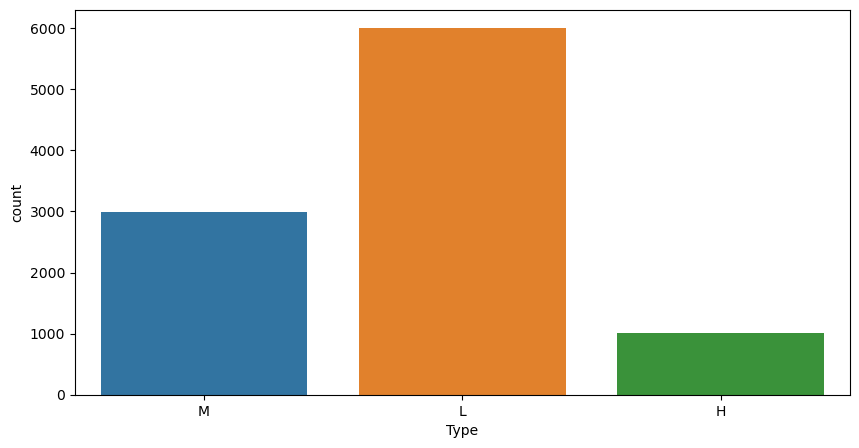

                          Failure Type  Veri Setindeki Yüzdelik Orani
No Failure                        9652                          96.52
Heat Dissipation Failure           112                           1.12
Power Failure                       95                           0.95
Overstrain Failure                  78                           0.78
Tool Wear Failure                   45                           0.45
Random Failures                     18                           0.18


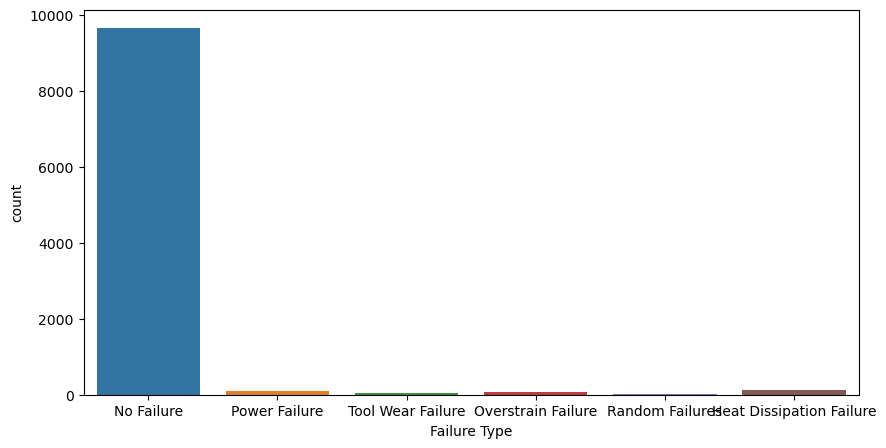

   Target  Veri Setindeki Yüzdelik Orani
0    9661                          96.61
1     339                           3.39


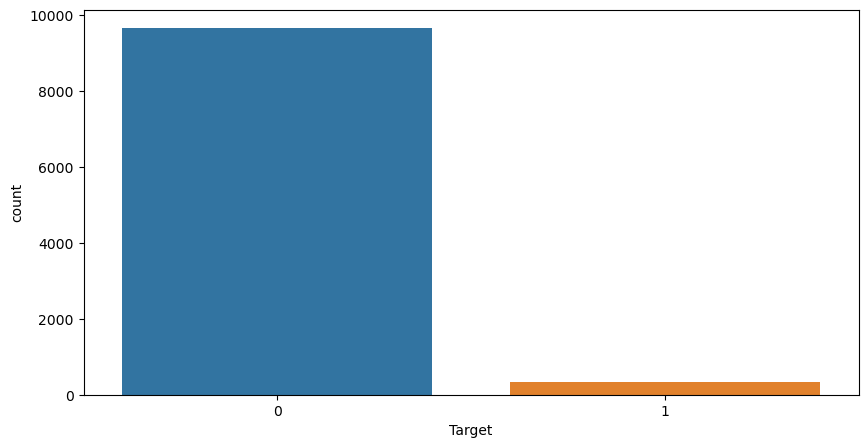

In [23]:
categorik_degisken_ozeti(df,kategorik_degiskenler)

In [24]:
def sayisal_degisken_ozeti(dataframe,sayisal_degiskenler,plot=True):#This function extracts the summary of the Numerical Variables
    for col in sayisal_degiskenler:
        print(pd.DataFrame({col : dataframe[col].describe().T}))
        
        if plot:
            plt.figure(figsize=(25,12))
            sns.histplot(data=dataframe,x=col,kde=True)
            plt.grid()
            plt.show(block=True)

       Air temperature [K]
count             10000.00
mean                300.00
std                   2.00
min                 295.30
25%                 298.30
50%                 300.10
75%                 301.50
max                 304.50


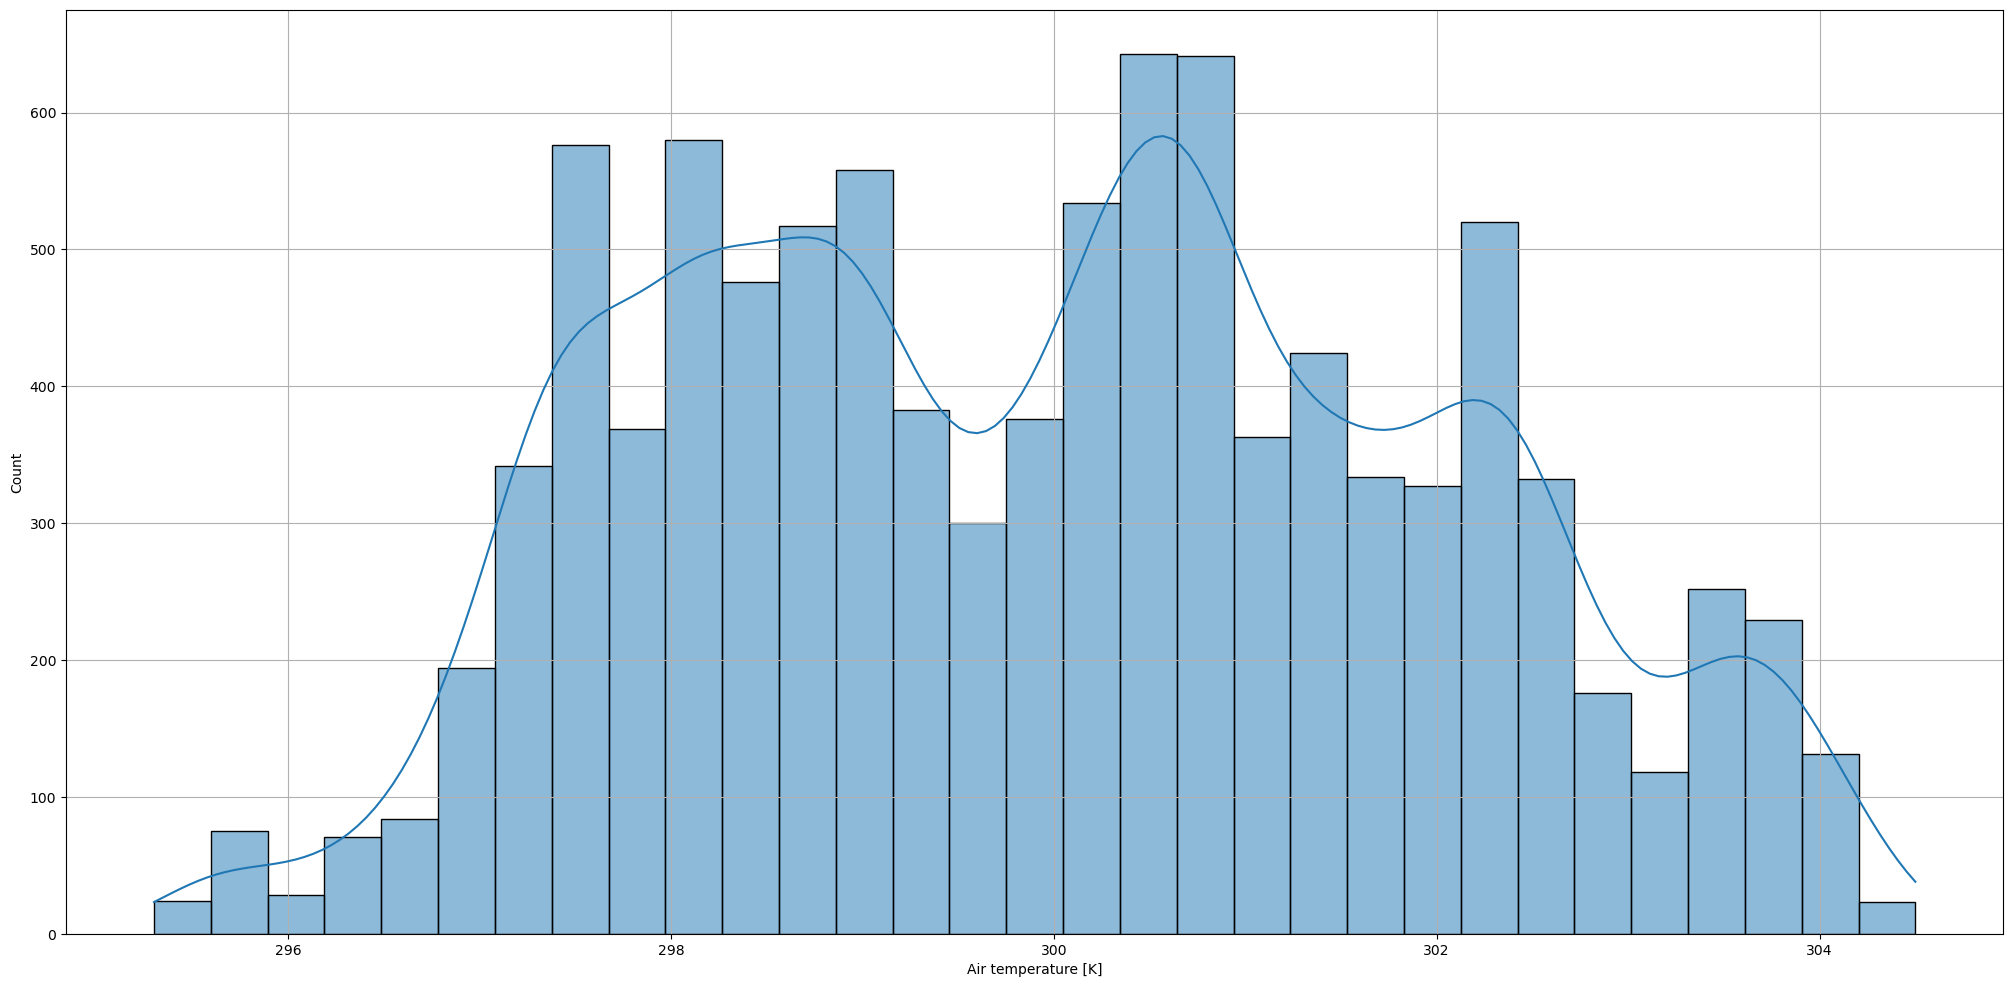

       Process temperature [K]
count                 10000.00
mean                    310.01
std                       1.48
min                     305.70
25%                     308.80
50%                     310.10
75%                     311.10
max                     313.80


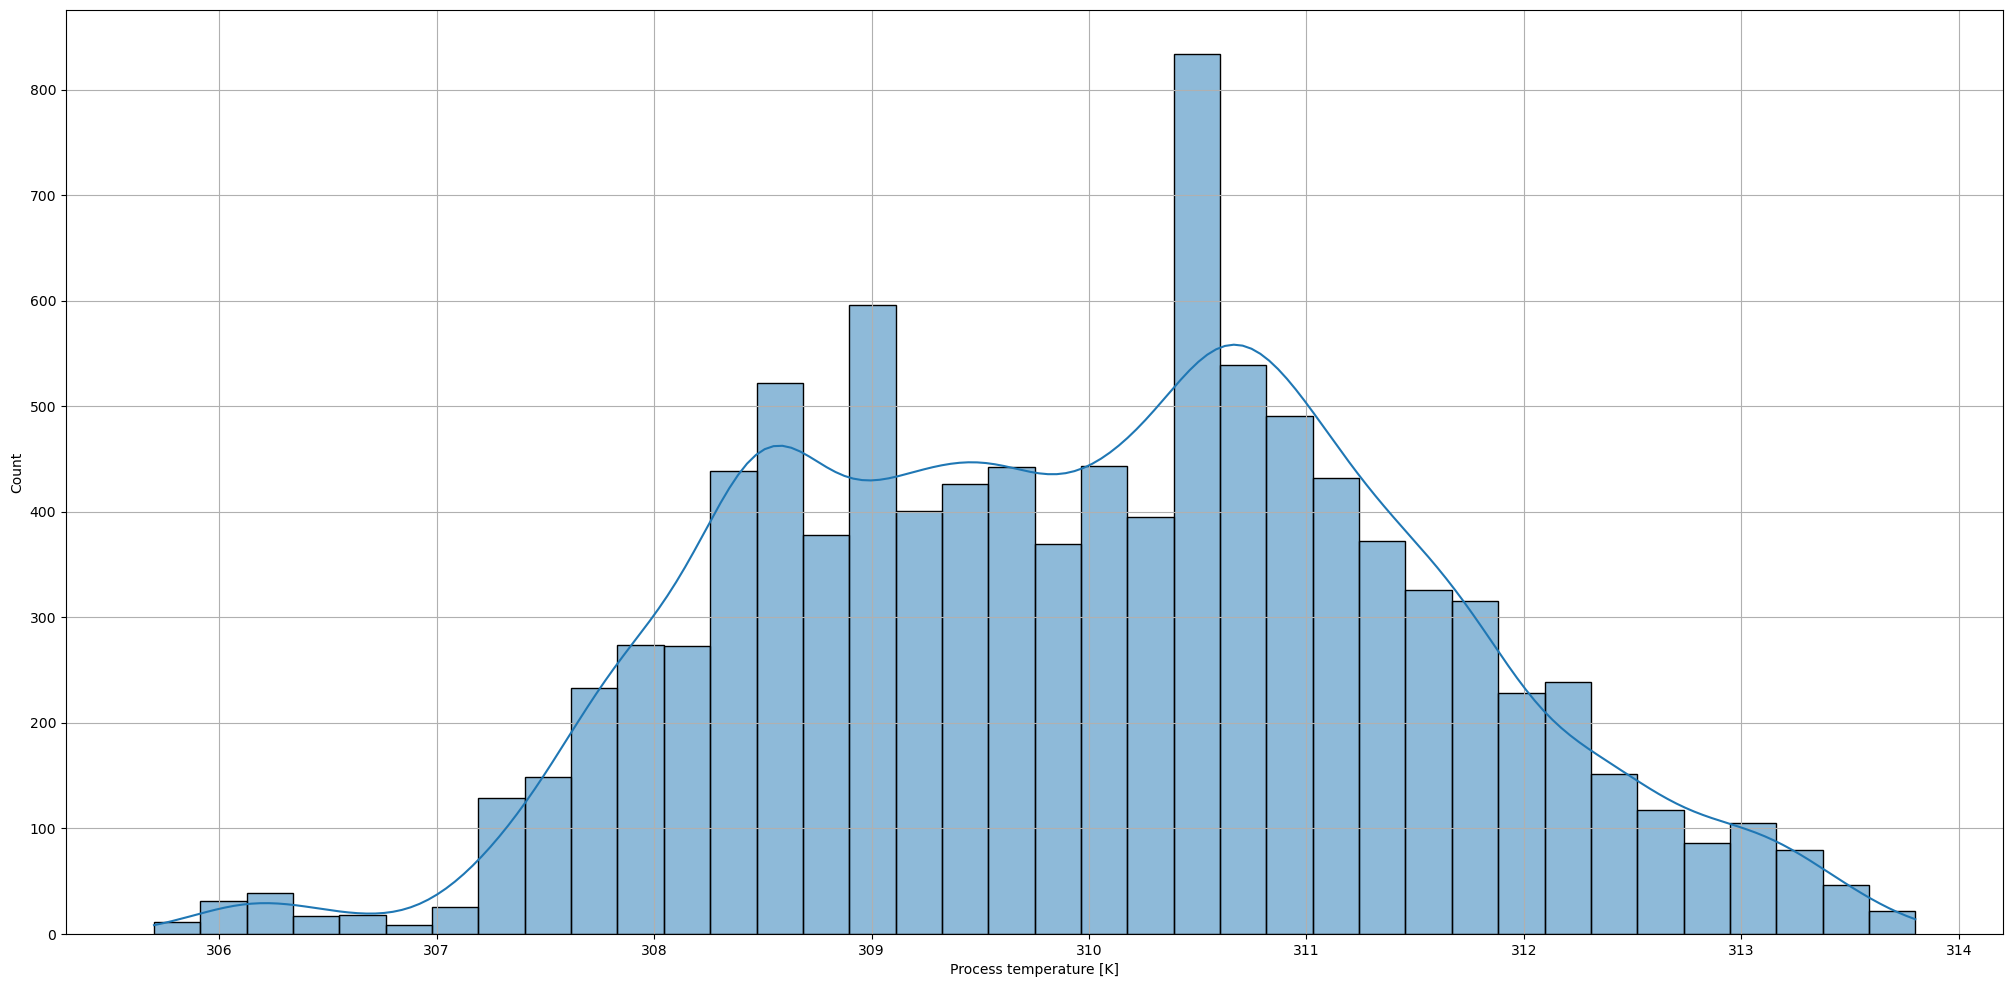

       Rotational speed [rpm]
count                10000.00
mean                  1538.78
std                    179.28
min                   1168.00
25%                   1423.00
50%                   1503.00
75%                   1612.00
max                   2886.00


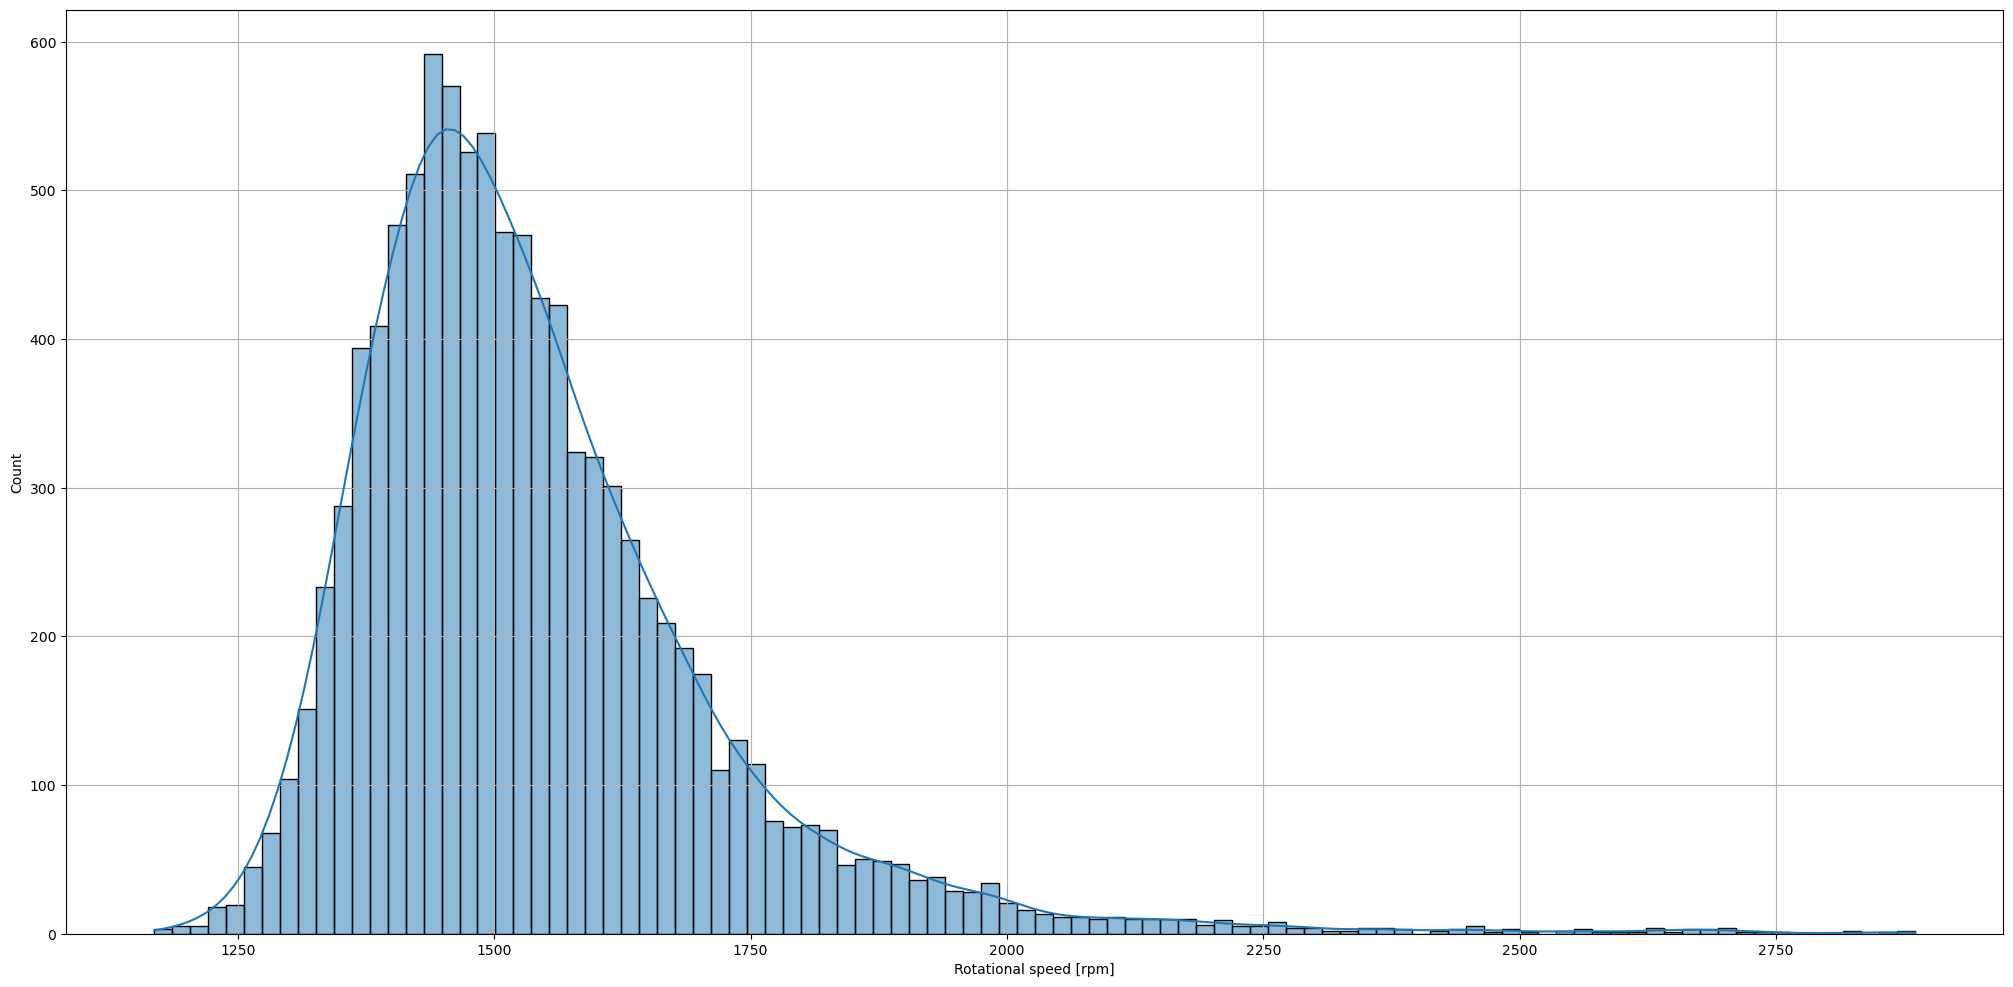

       Torque [Nm]
count     10000.00
mean         39.99
std           9.97
min           3.80
25%          33.20
50%          40.10
75%          46.80
max          76.60


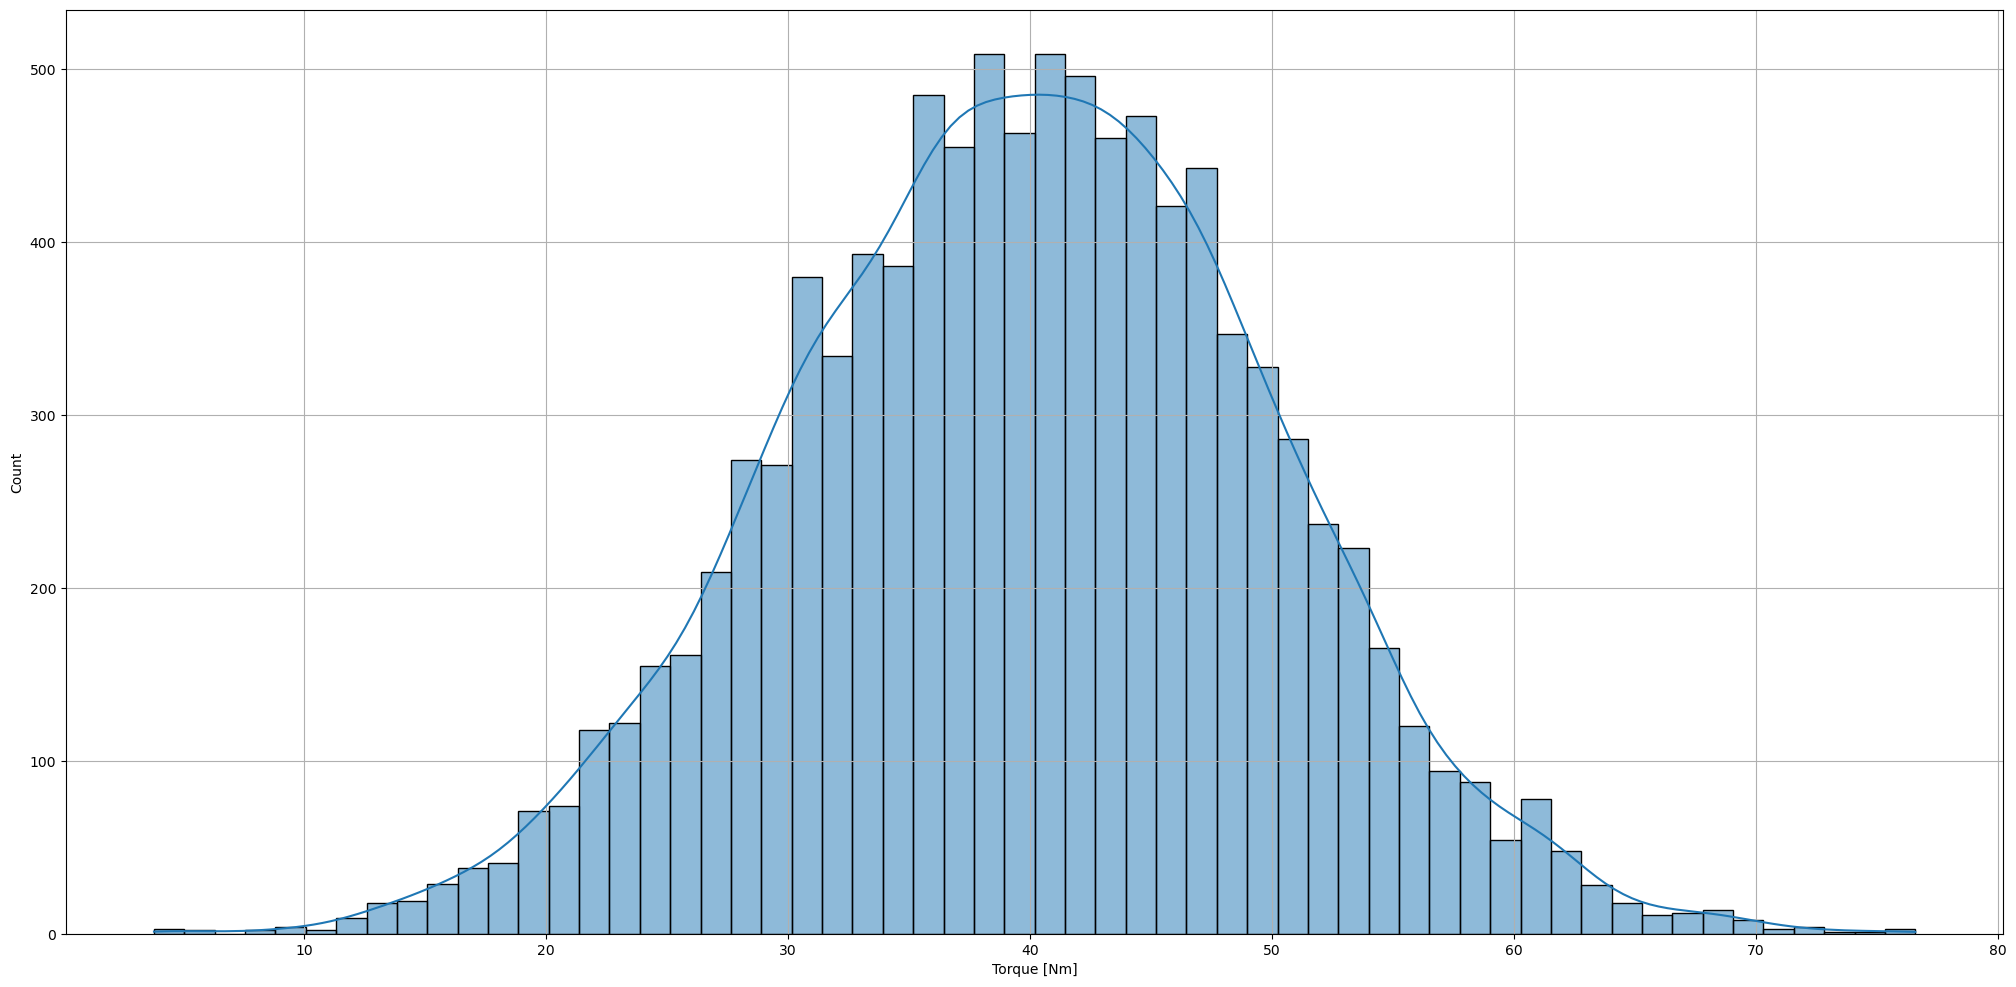

       Tool wear [min]
count         10000.00
mean            107.95
std              63.65
min               0.00
25%              53.00
50%             108.00
75%             162.00
max             253.00


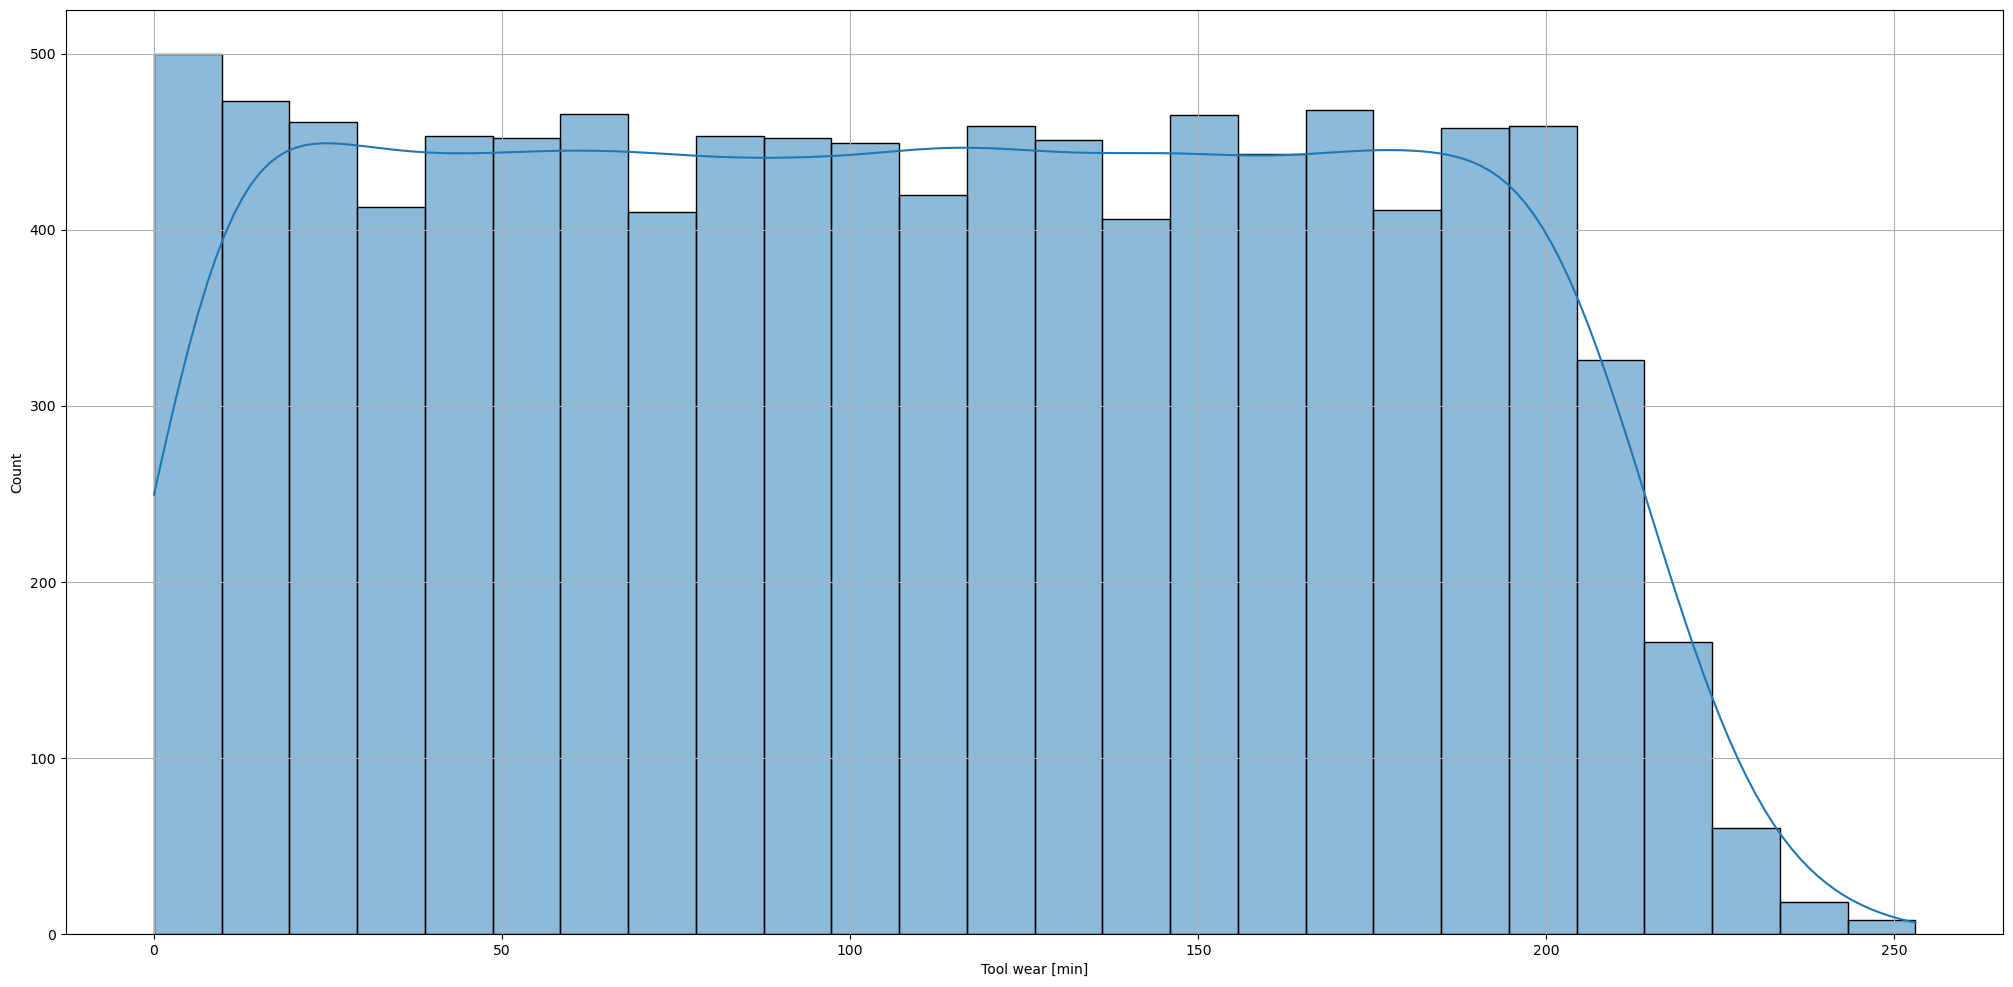

In [25]:
sayisal_degisken_ozeti(df,sayisal_degiskenler)

In [26]:
df["Date"].iloc[500]

Timestamp('2024-01-06 05:00:00')

In [27]:
df["Date"].dtype

dtype('<M8[ns]')

In [28]:
df["Date"] = pd.to_datetime(df["Date"],format="%Y-%m-%d")

<AxesSubplot:xlabel='Date', ylabel='Tool wear [min]'>

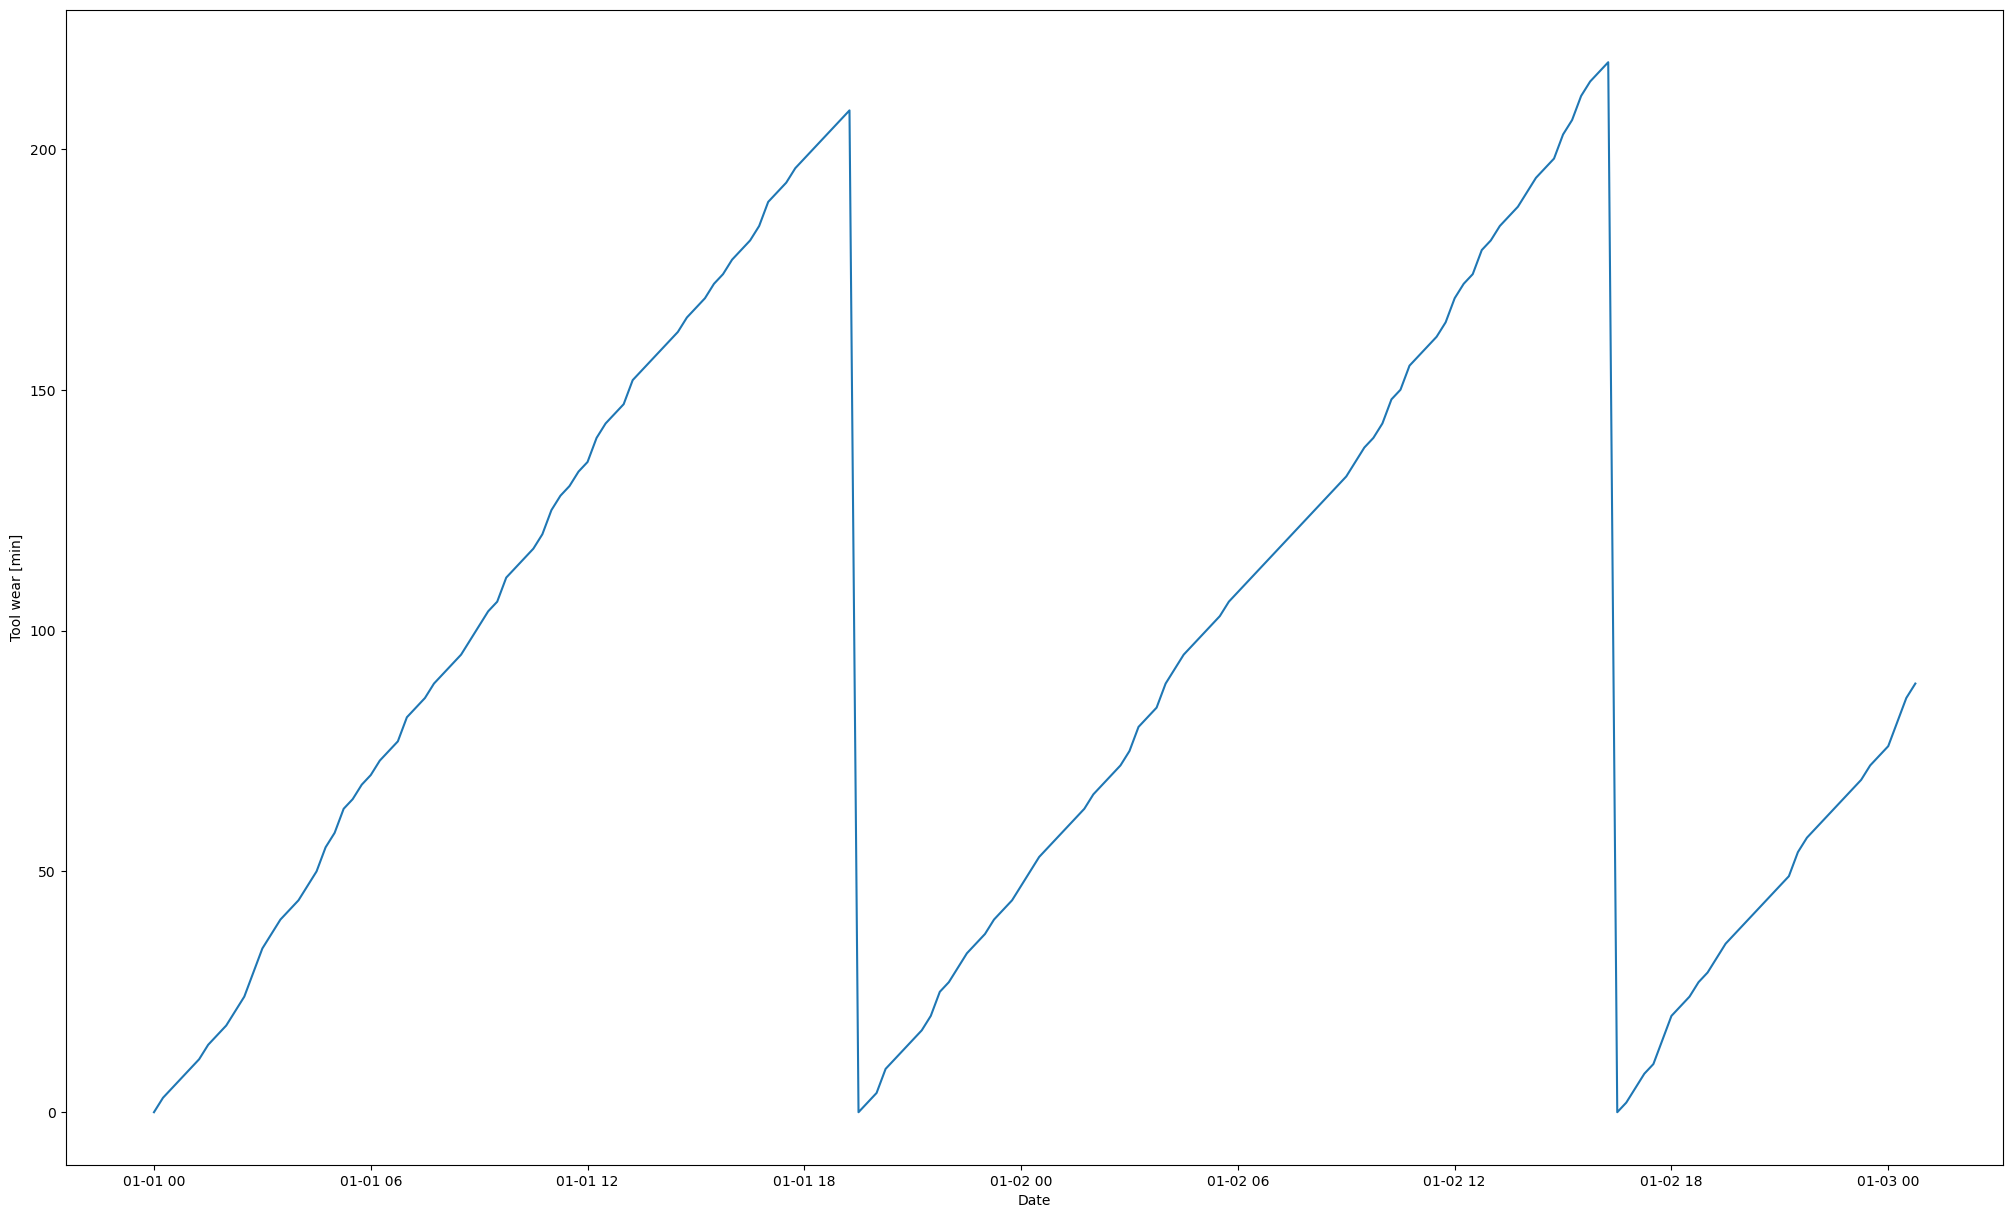

In [29]:
plt.figure(figsize=(25, 15))
sns.lineplot(data=df[0:196],x="Date",y="Tool wear [min]")

In [30]:
def zamana_gore_sayisal_veri_özeti(dataframe,sayisal_degiskenler):#This function analyzes numeric variables based on time
    for col in sayisal_degiskenler:
        plt.figure(figsize=(25,8))
        sns.lineplot(data=dataframe,x="Date",y=col)
        plt.grid()
        plt.show(block=False)

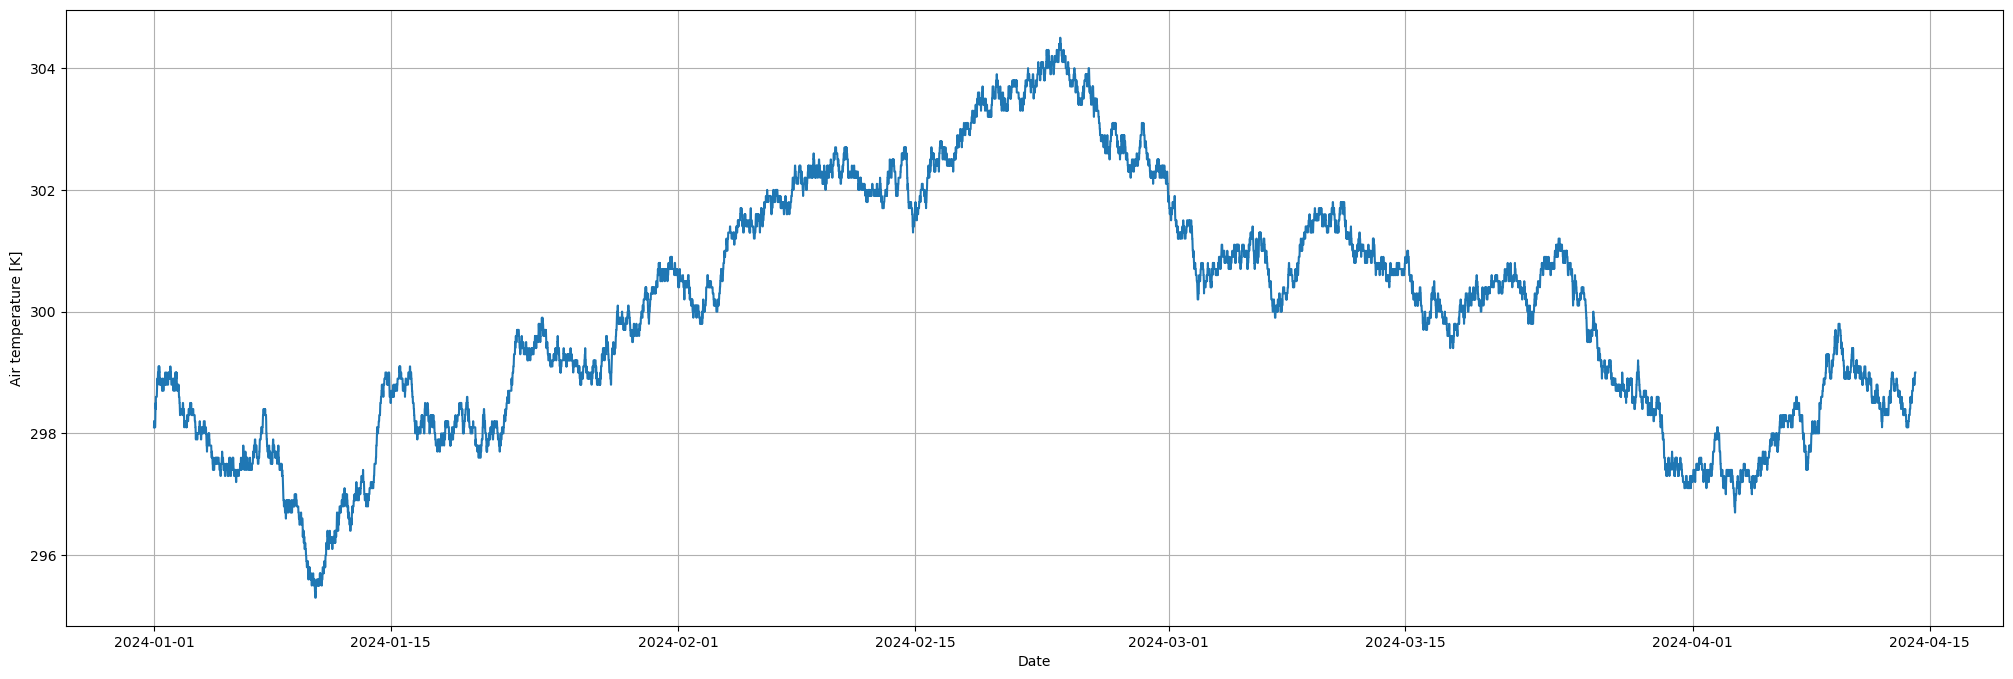

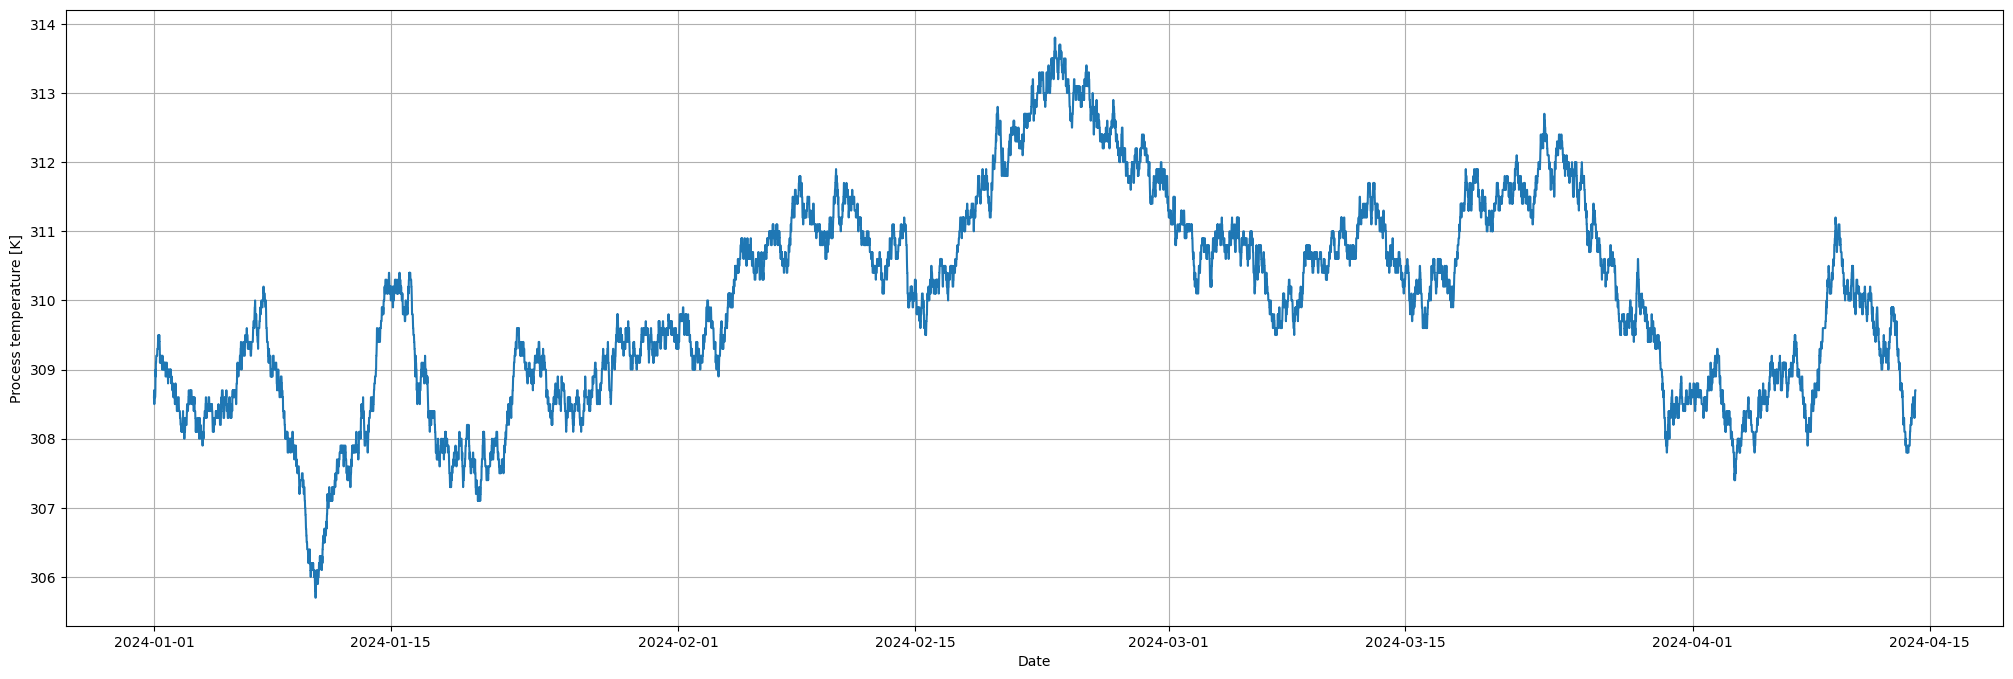

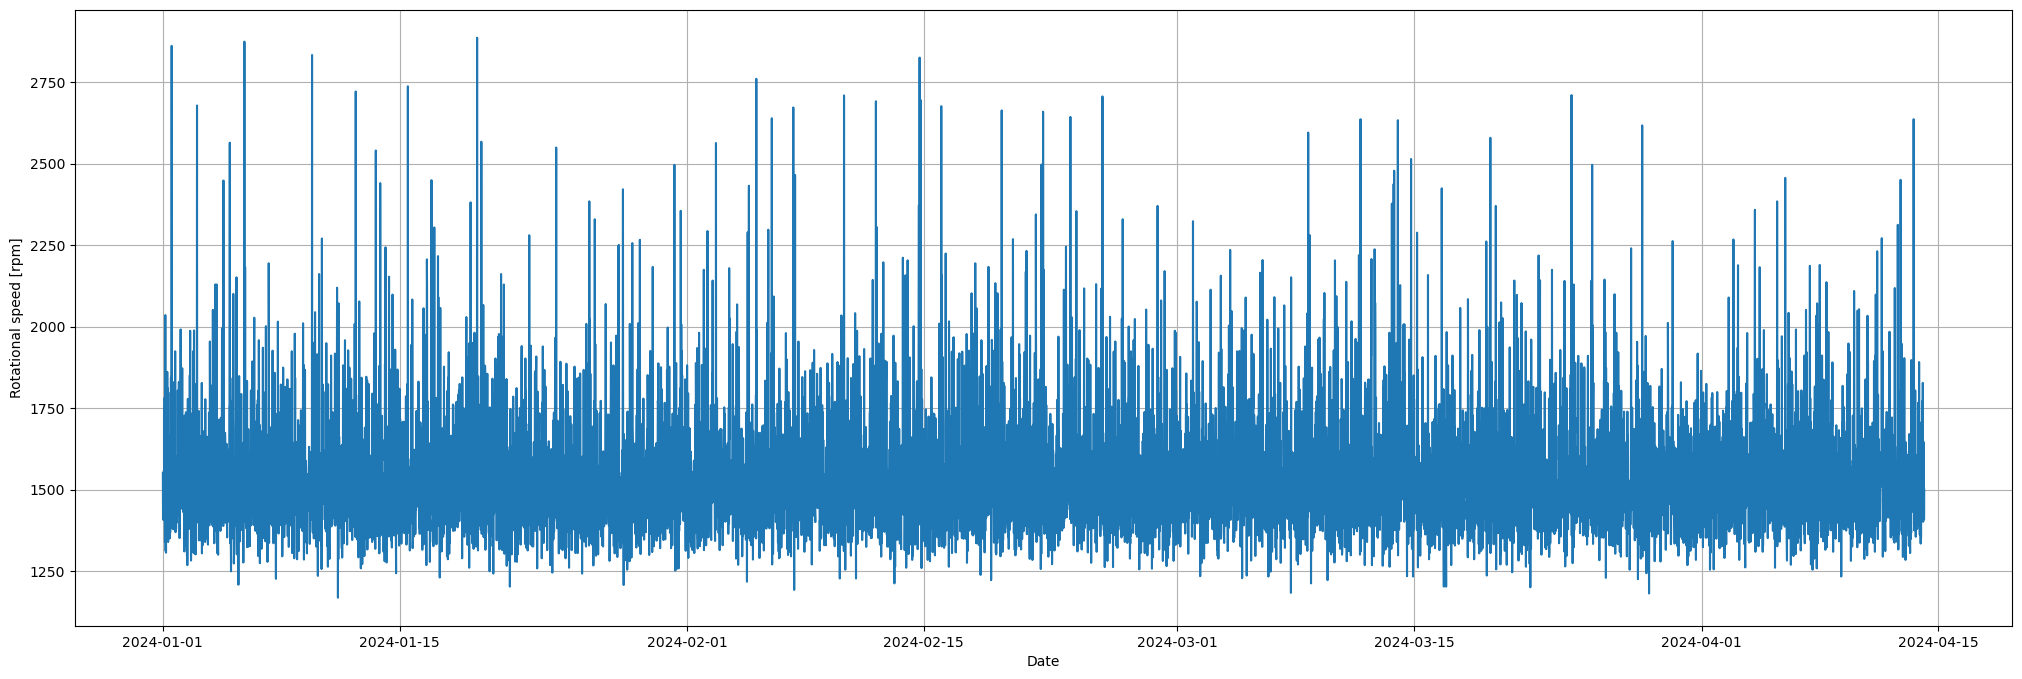

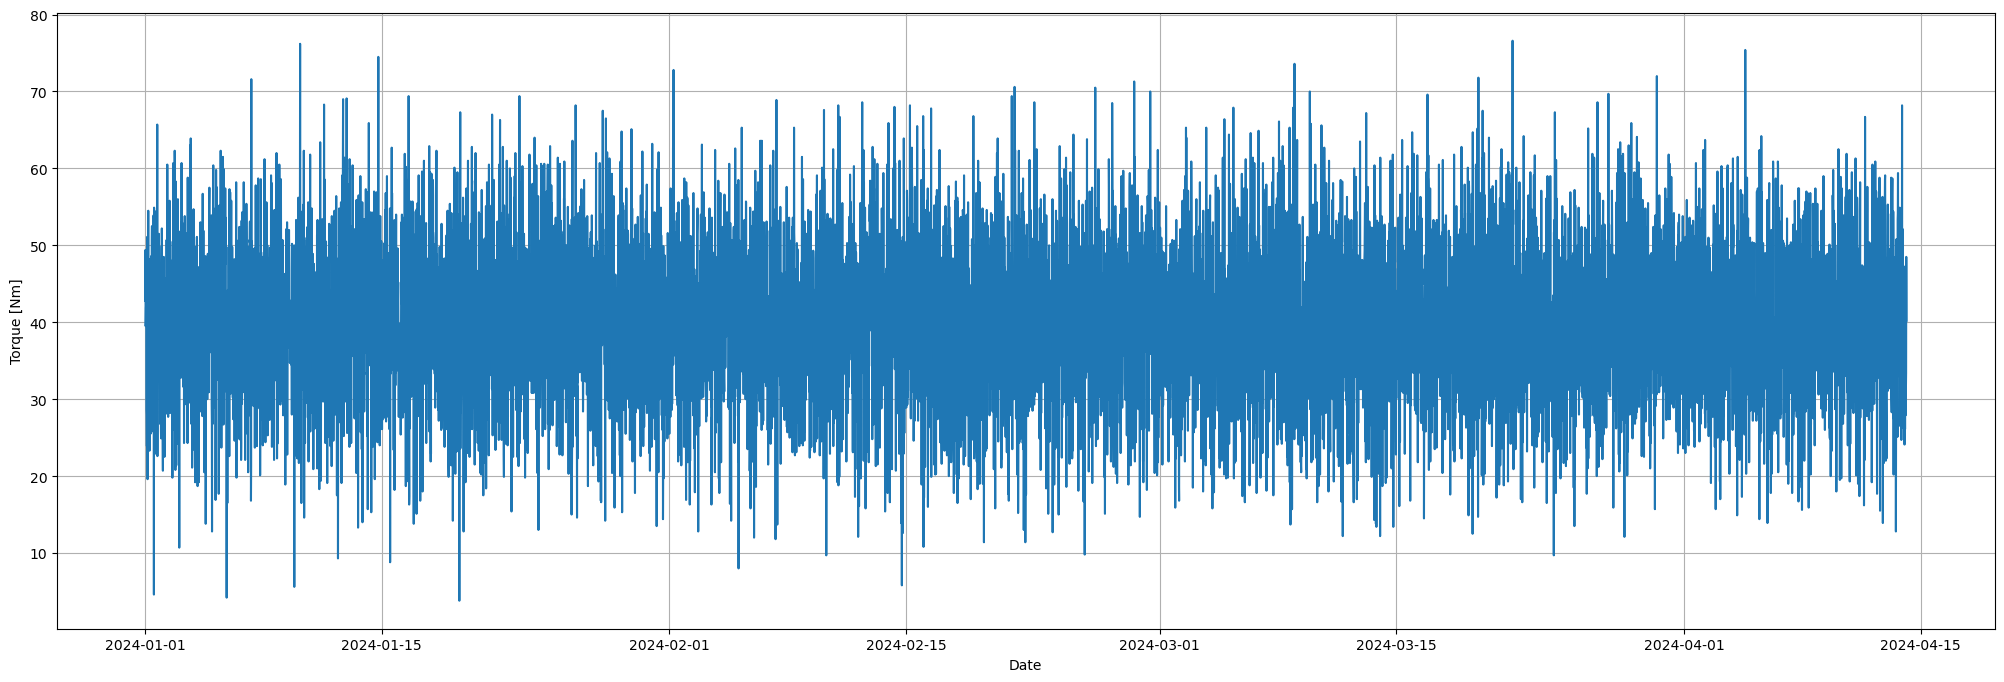

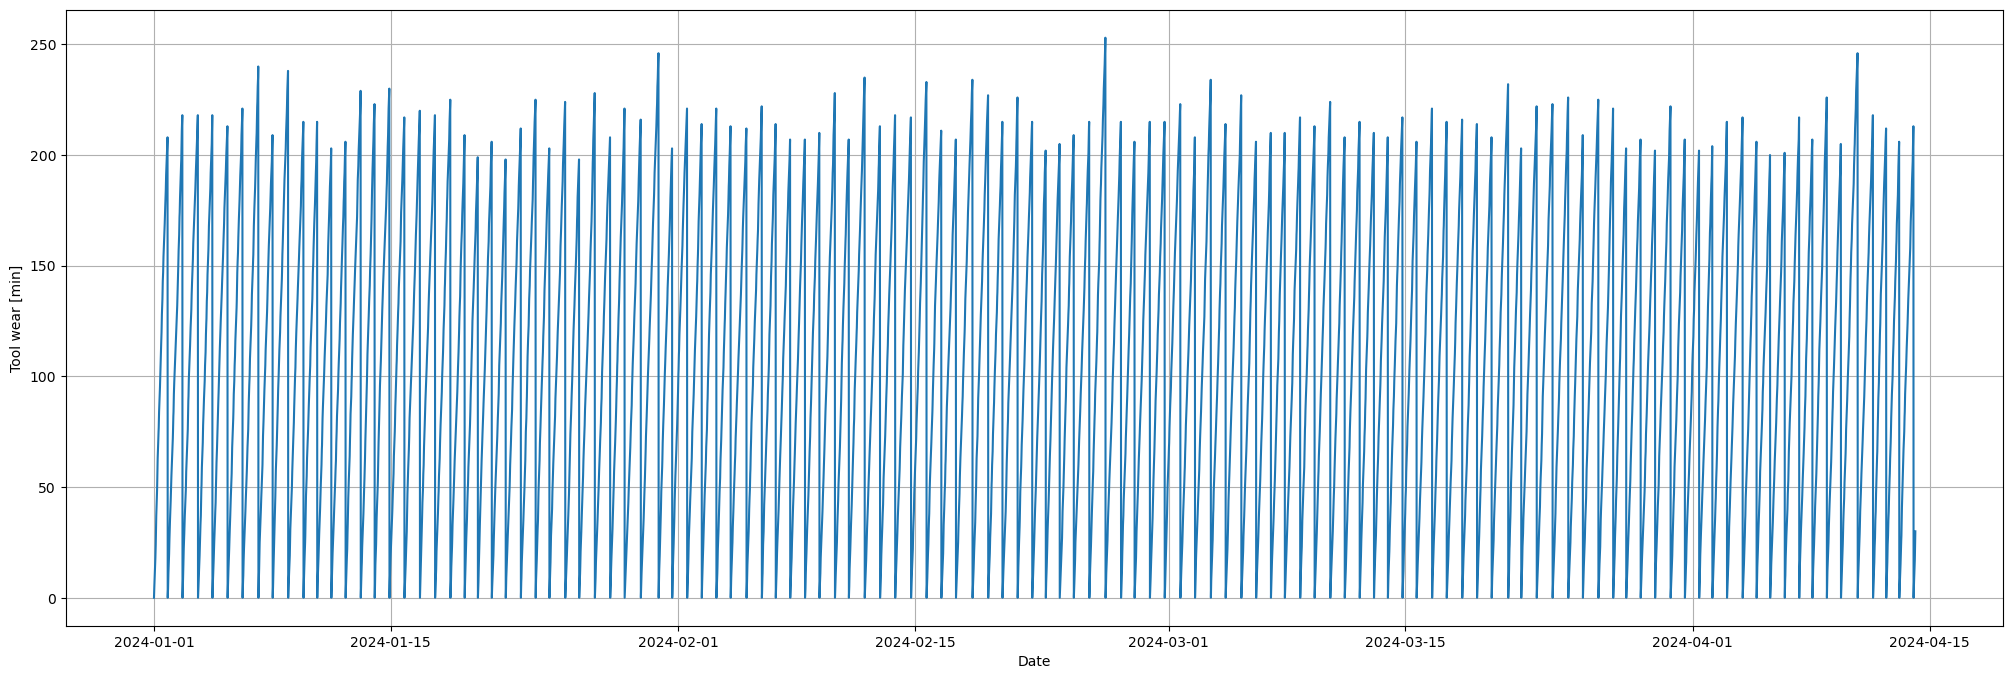

In [31]:
zamana_gore_sayisal_veri_özeti(df,sayisal_degiskenler)

In [32]:
df.loc[((df["Target"] == 1) & (df["Failure Type"] == "No Failure"))]

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Date
1437,H,298.80,309.90,1439,45.20,40,1,No Failure,2024-01-15 23:15:00
2749,M,299.70,309.20,1685,28.90,179,1,No Failure,2024-01-29 15:15:00
4044,M,301.90,310.90,1419,47.70,20,1,No Failure,2024-02-12 03:00:00
4684,M,303.60,311.80,1421,44.80,101,1,No Failure,2024-02-18 19:00:00
5536,M,302.30,311.80,1363,54.00,119,1,No Failure,2024-02-27 16:00:00
5941,L,300.60,310.70,1438,48.50,78,1,No Failure,2024-03-02 21:15:00
6478,L,300.50,309.80,1663,29.10,145,1,No Failure,2024-03-08 11:30:00
8506,L,298.40,309.60,1710,27.30,163,1,No Failure,2024-03-29 14:30:00
9015,L,297.20,308.10,1431,49.70,210,1,No Failure,2024-04-03 21:45:00


In [33]:
df.drop(list(df.loc[((df["Target"] == 1) & (df["Failure Type"] == "No Failure"))].index),axis=0,inplace=True)

In [34]:
df.iloc[1437]

Type                                         L
Air temperature [K]                     298.80
Process temperature [K]                 309.90
Rotational speed [rpm]                    1482
Torque [Nm]                              39.10
Tool wear [min]                             45
Target                                       0
Failure Type                        No Failure
Date                       2024-01-15 23:30:00
Name: 1438, dtype: object

In [35]:
list(df.loc[((df["Target"] == 1) & (df["Failure Type"] == "No Failure"))].index)

[]

In [36]:
def hareketli_ortalama(datafram,sayisal_degiskenler,window_size = 10):#This function adds a moving average of 10 data for numeric variables
    
    for col in sayisal_degiskenler:
        
        df[col].rolling(window=window_size).mean()

        plt.figure(figsize=(25, 8))

        plt.plot(df[col], label= f'Original {col}', color='navy')
        plt.plot(df[col].rolling(window=window_size).mean(), label=f'Moving Average (Window={window_size})', linestyle='--', color='darkorange')

        plt.xlabel('Date')
        plt.ylabel(col)
        plt.title('Original vs Moving Average')
        plt.legend()
        plt.show()
        

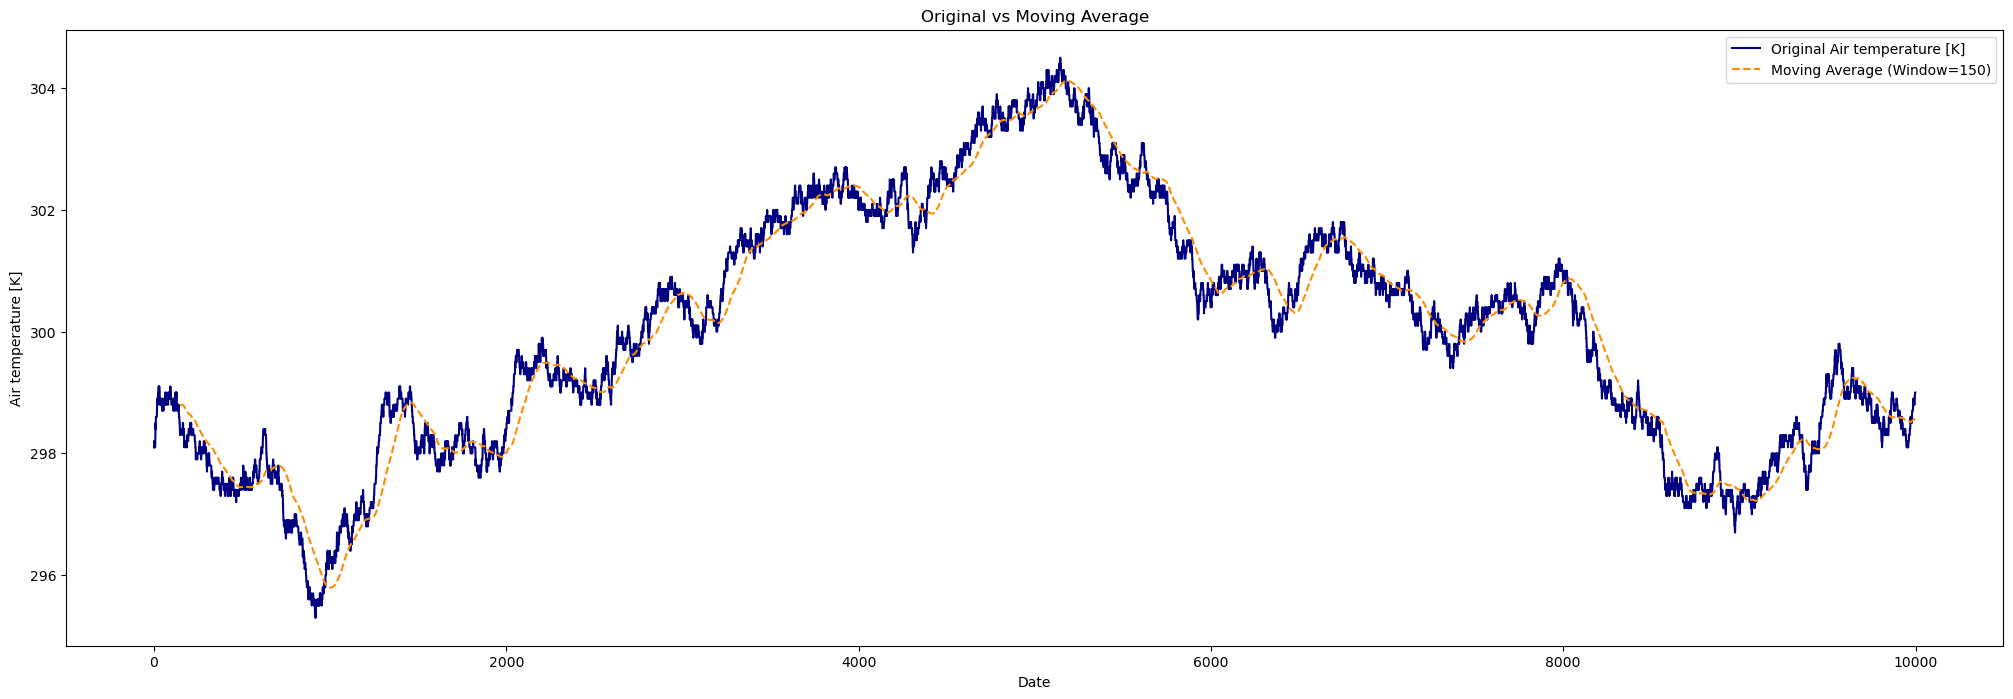

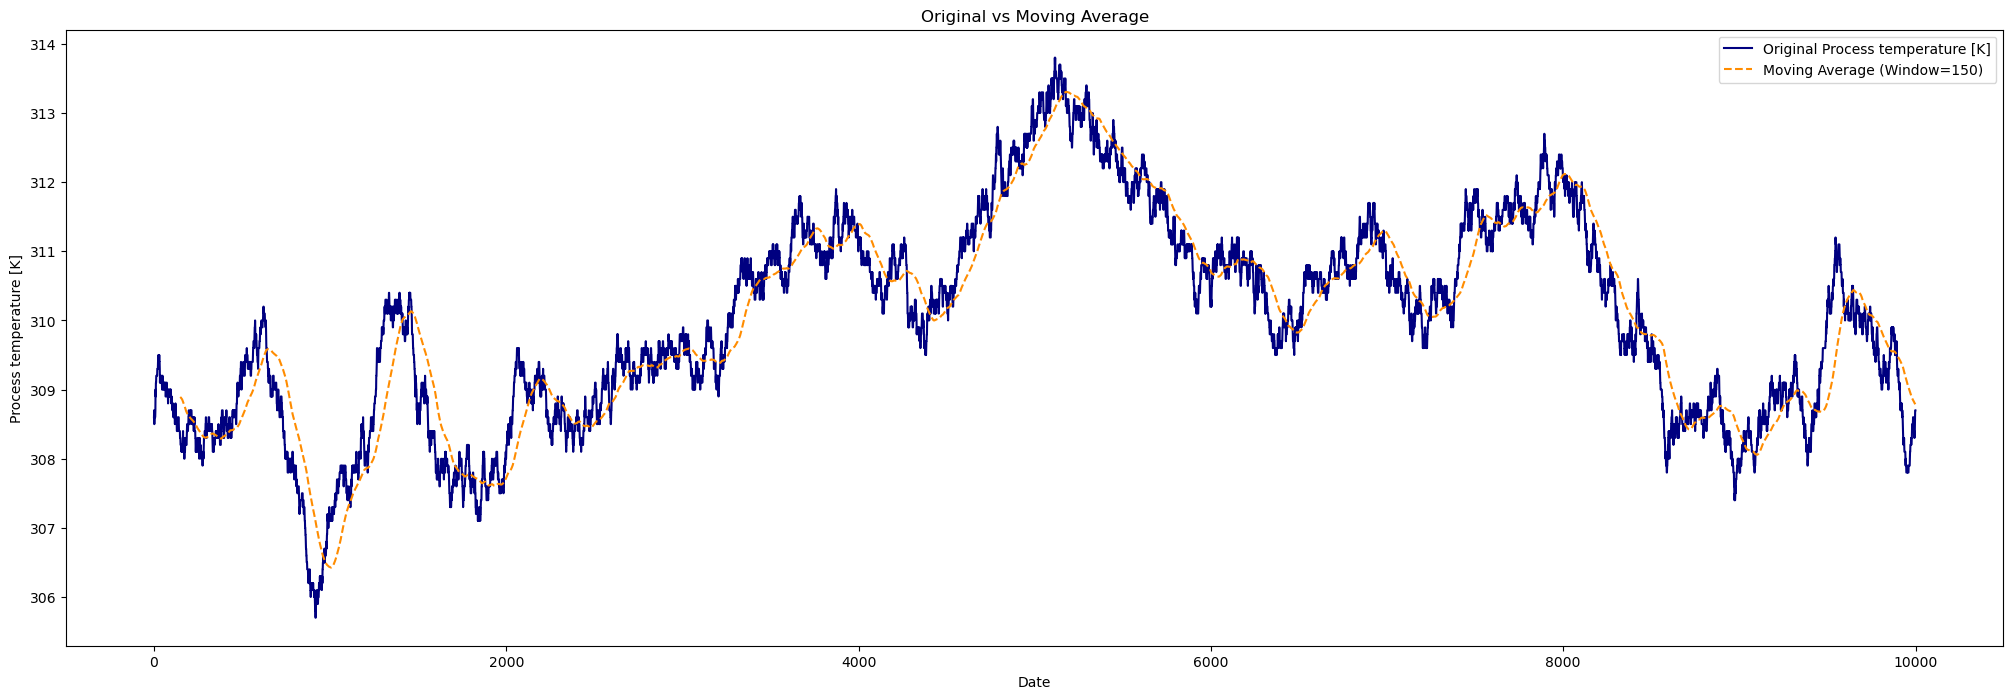

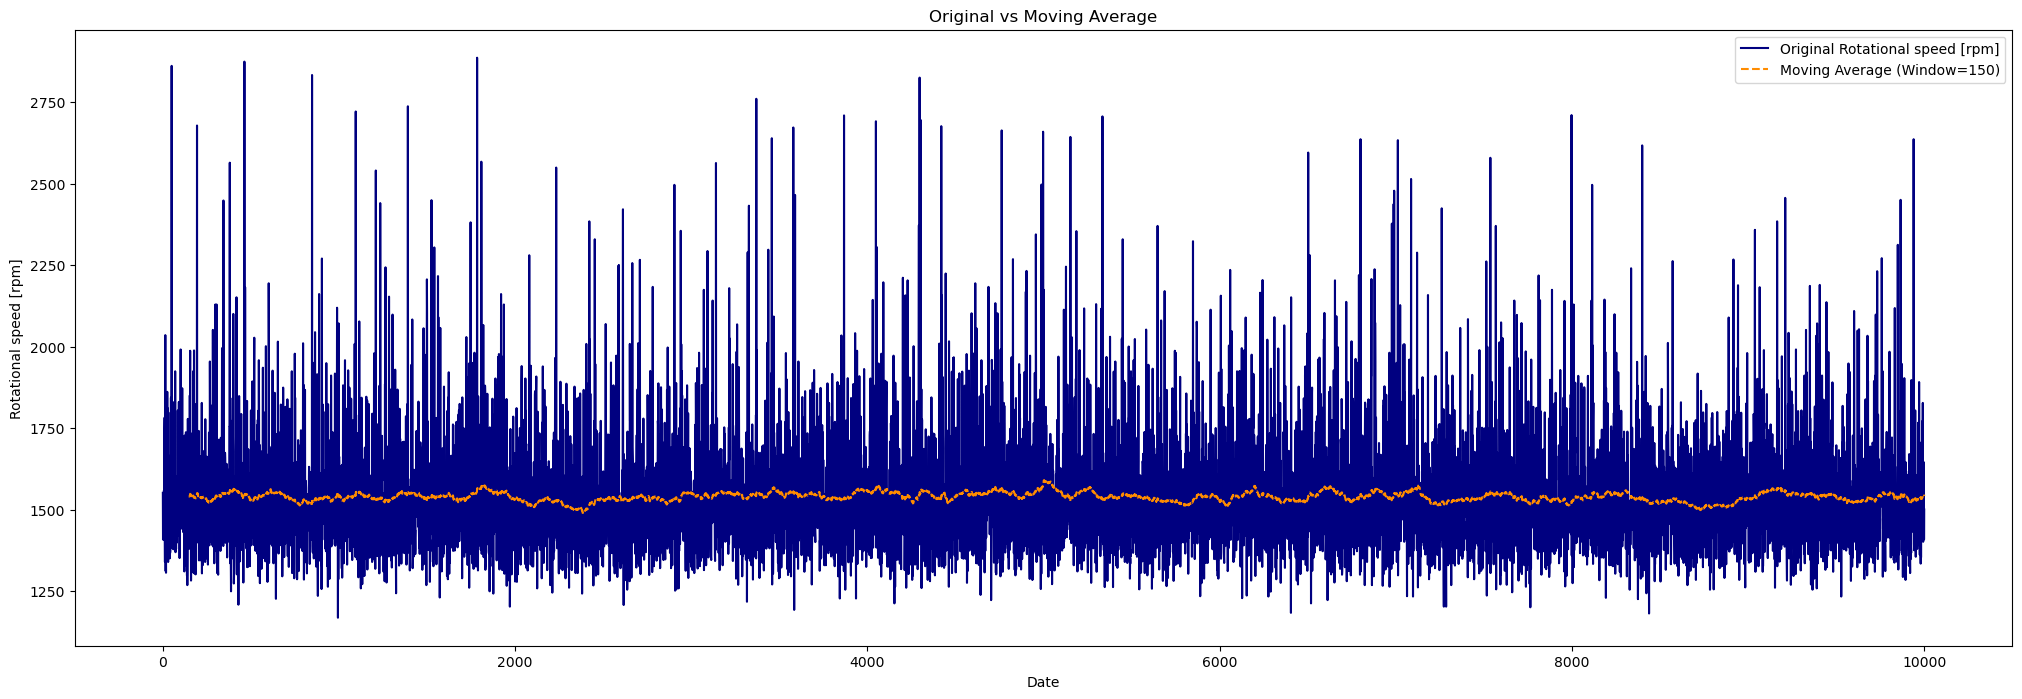

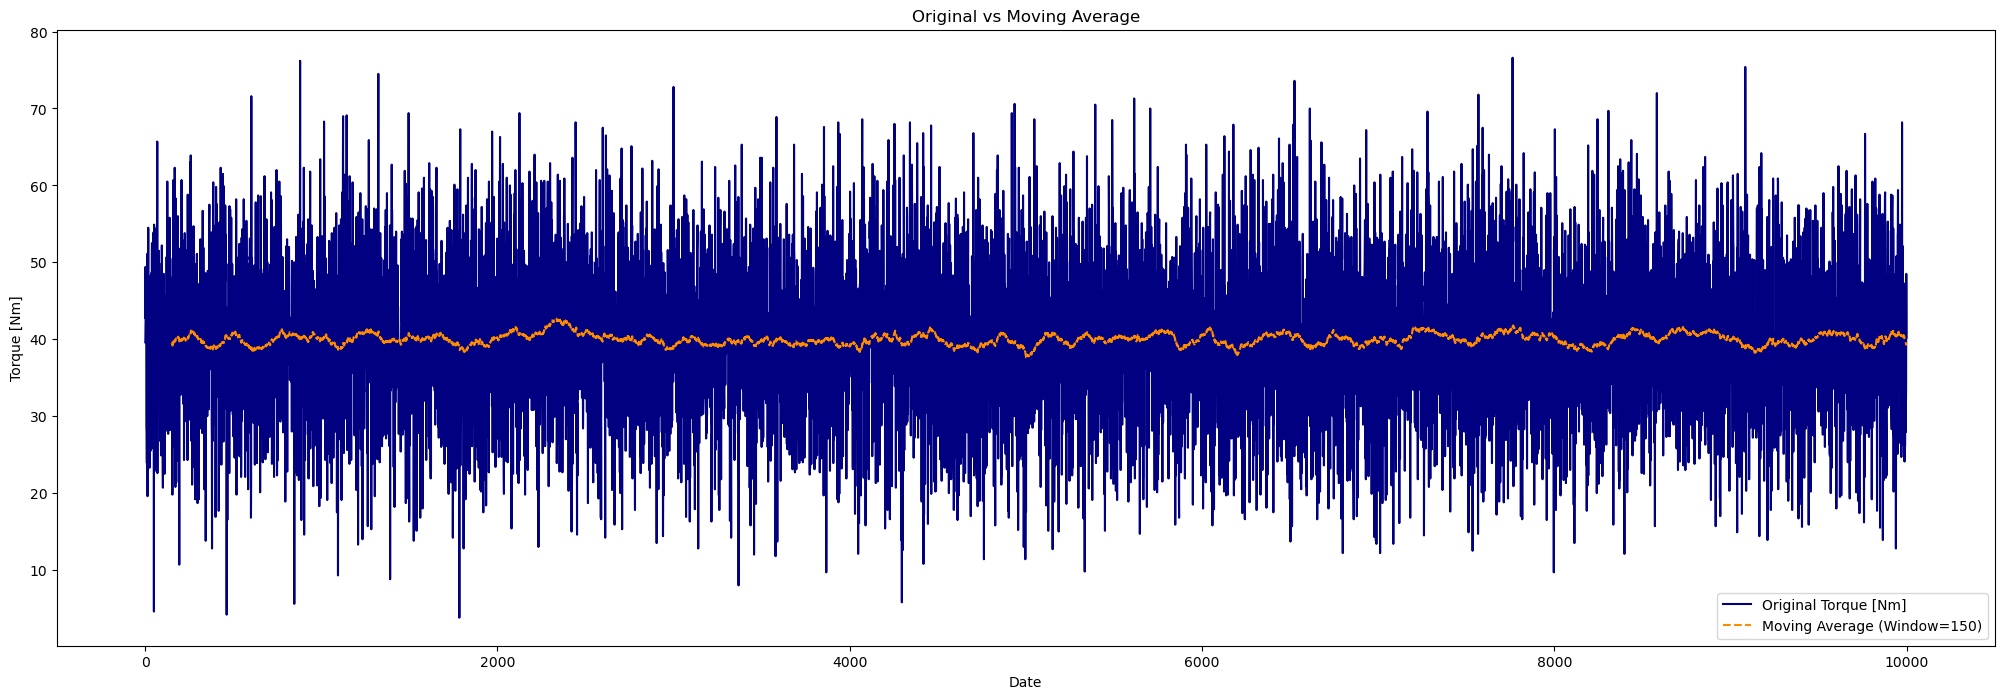

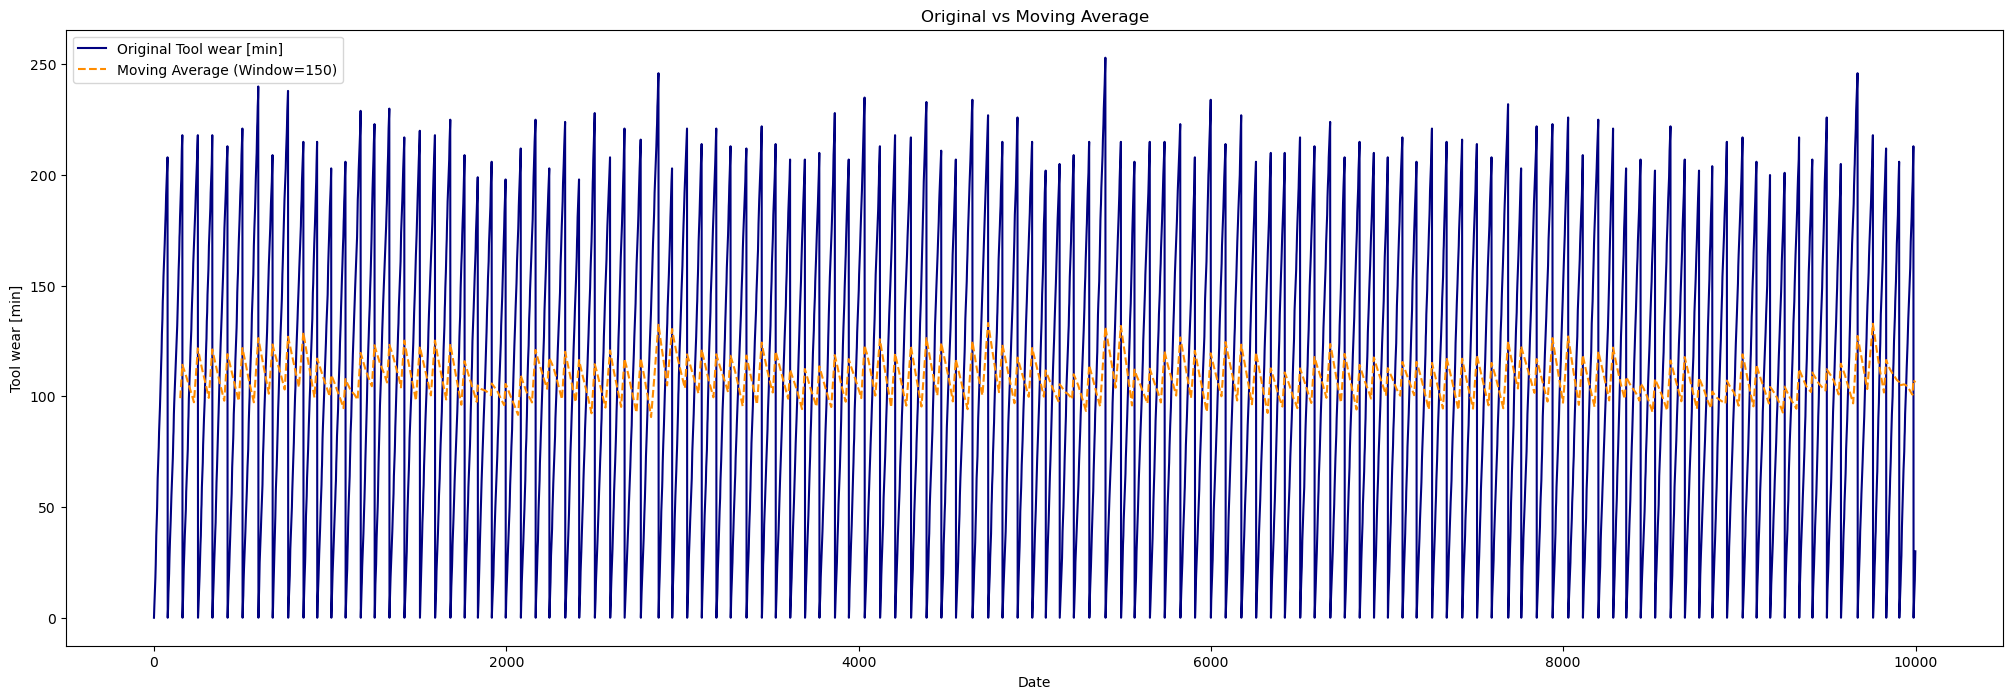

In [37]:
hareketli_ortalama(df,sayisal_degiskenler,150) # window_size = 150

In [38]:
def outlier_th(dataframe,col,q1=0.15,q3=0.85,plot=True):#This function takes outlier threshold for numeric variables and plots
    quar1 = dataframe[col].quantile(q1)
    quar3 = dataframe[col].quantile(q3)
    
    iqr = quar3 - quar1
    
    low_limit = quar1 - 1.5 * iqr
    up_limit = quar3 + 1.5 * iqr
    
    if plot:
        plt.figure(figsize=(25,8))
        sns.boxplot(data=dataframe,x=col,color="darkorange")
        plt.show(block=False)
    
    return low_limit,up_limit

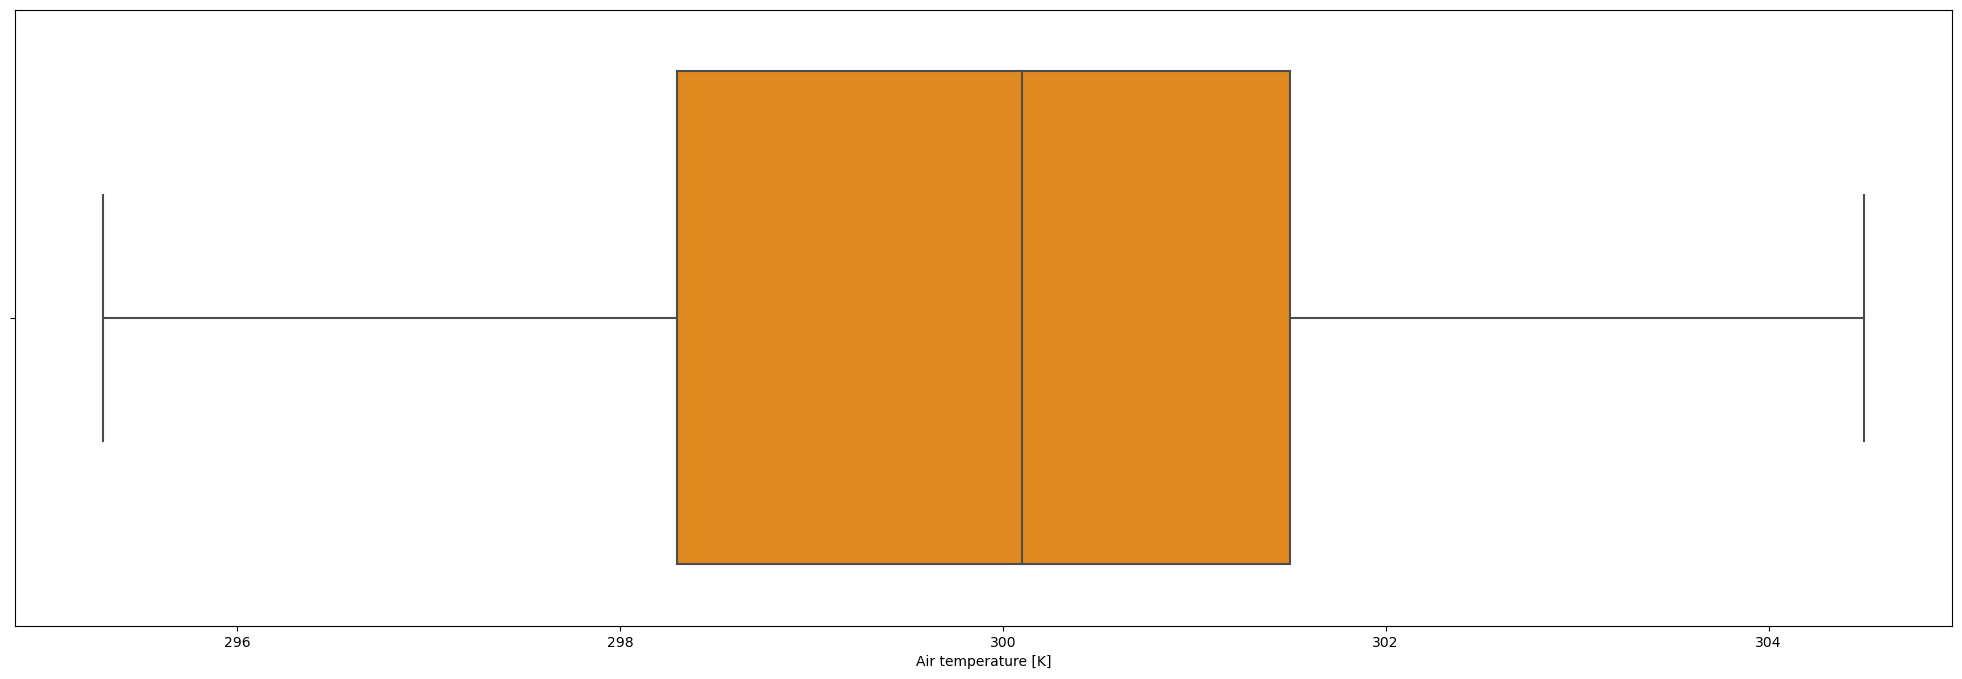

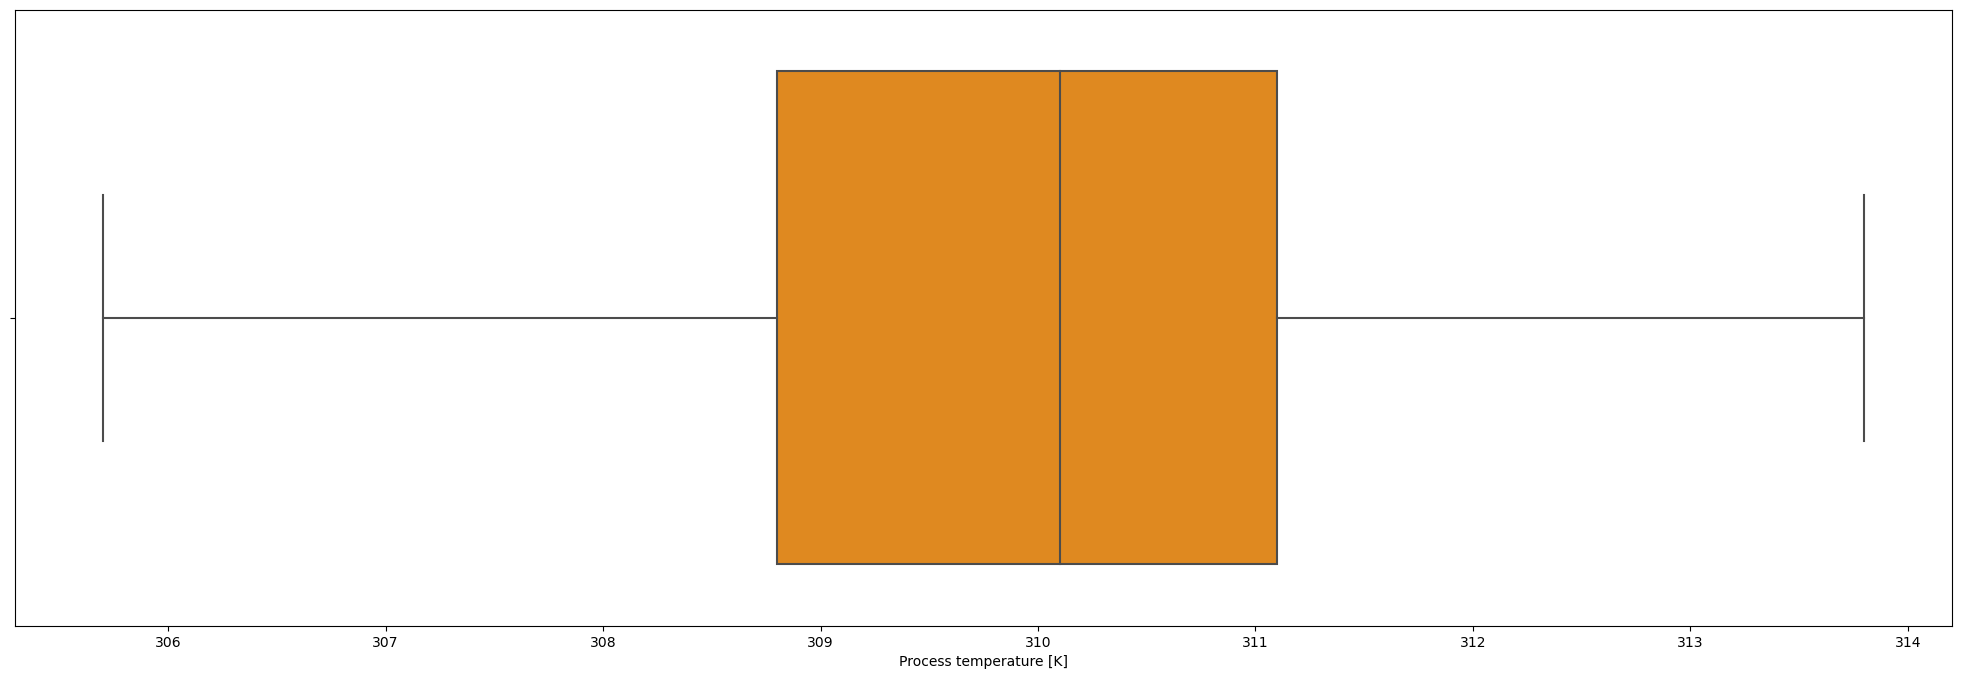

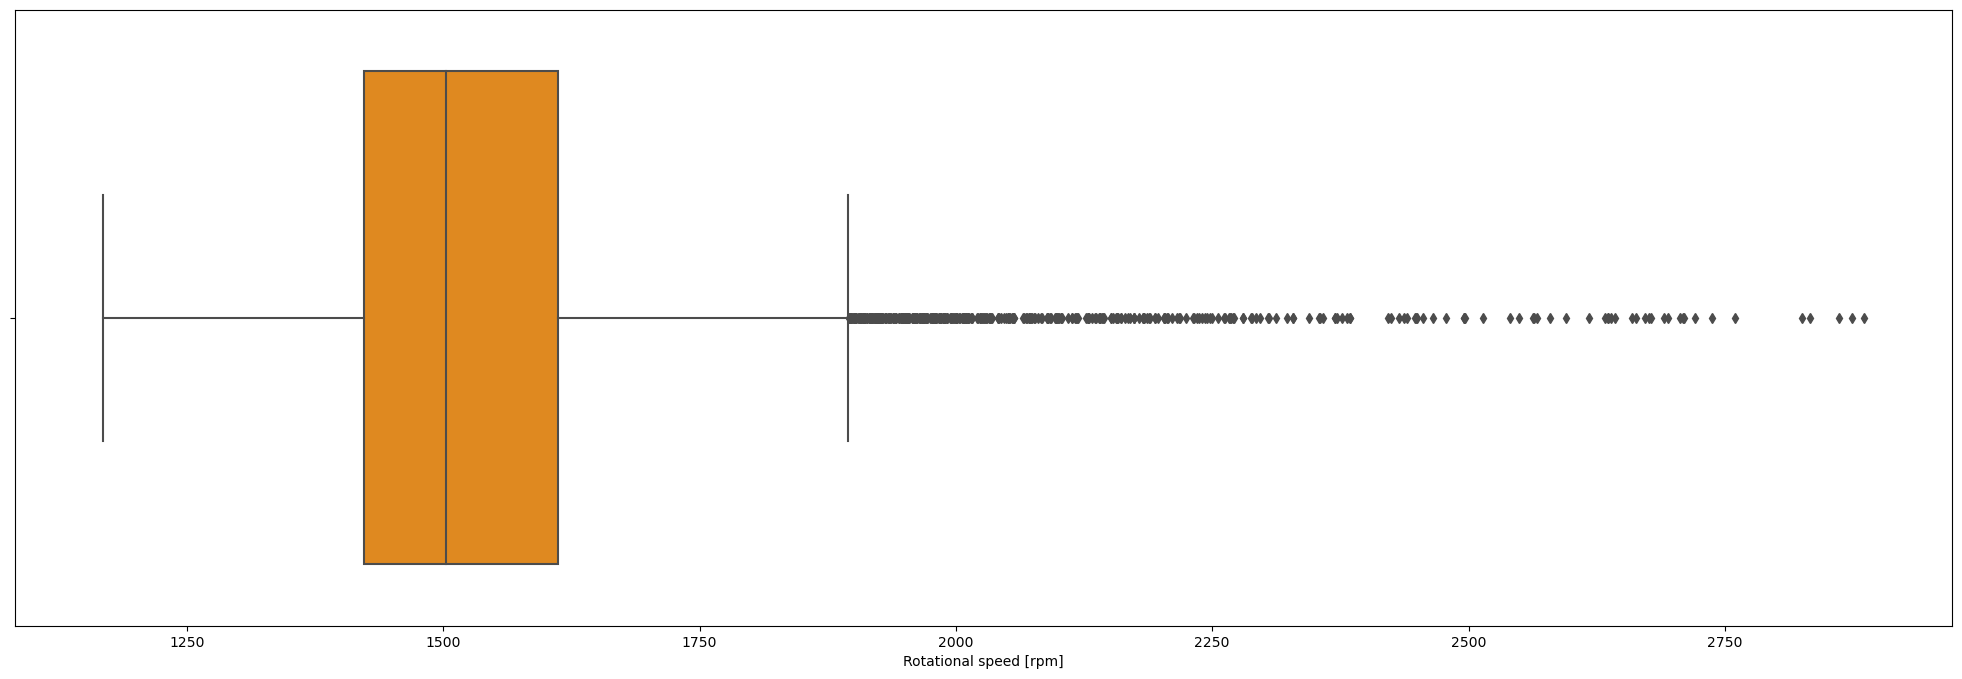

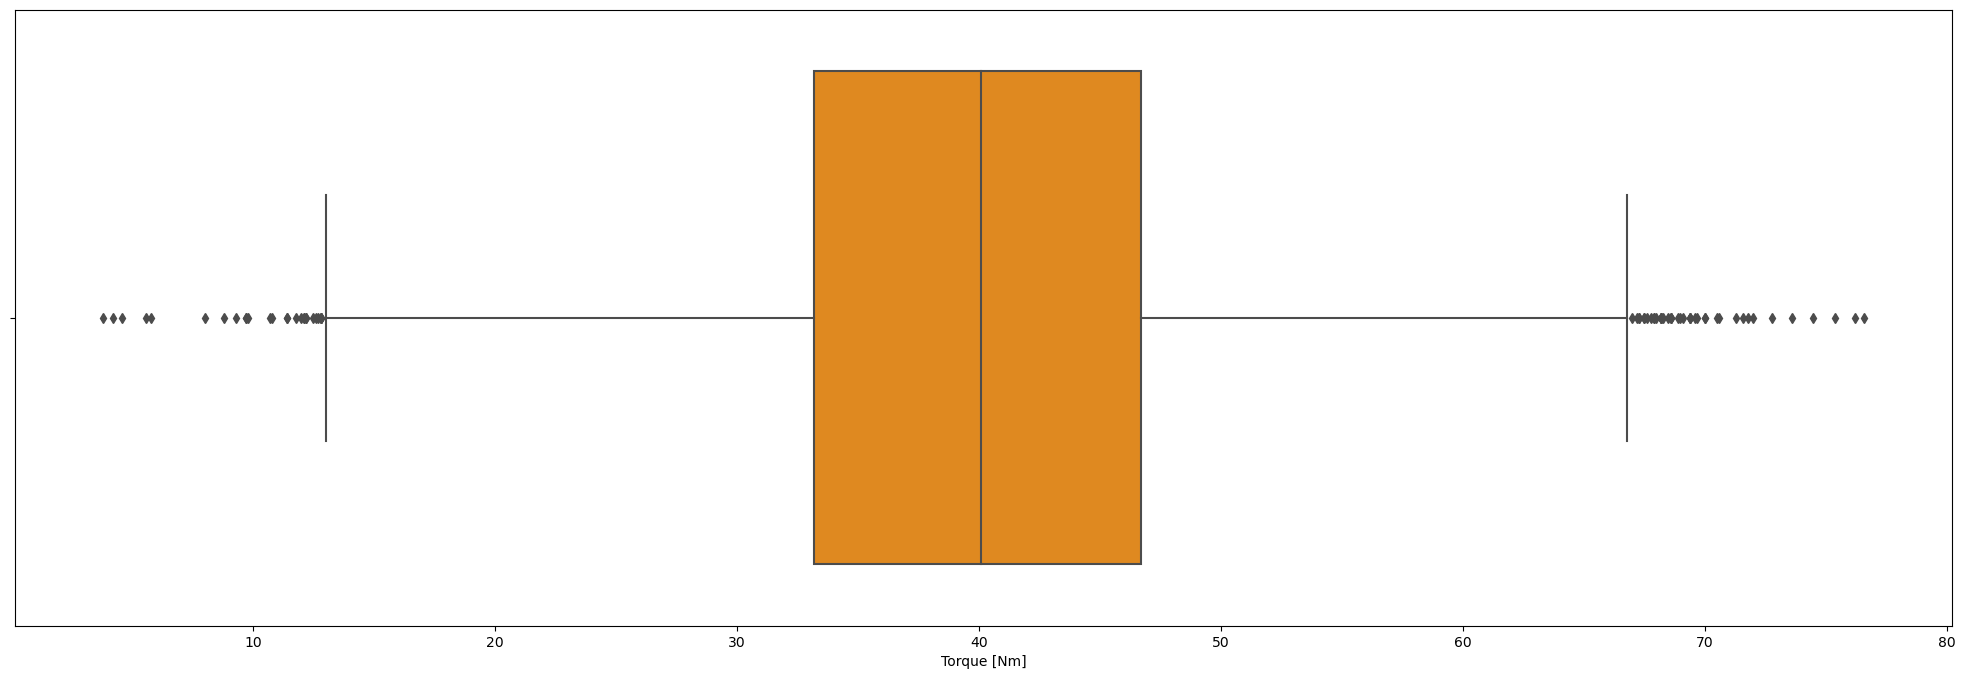

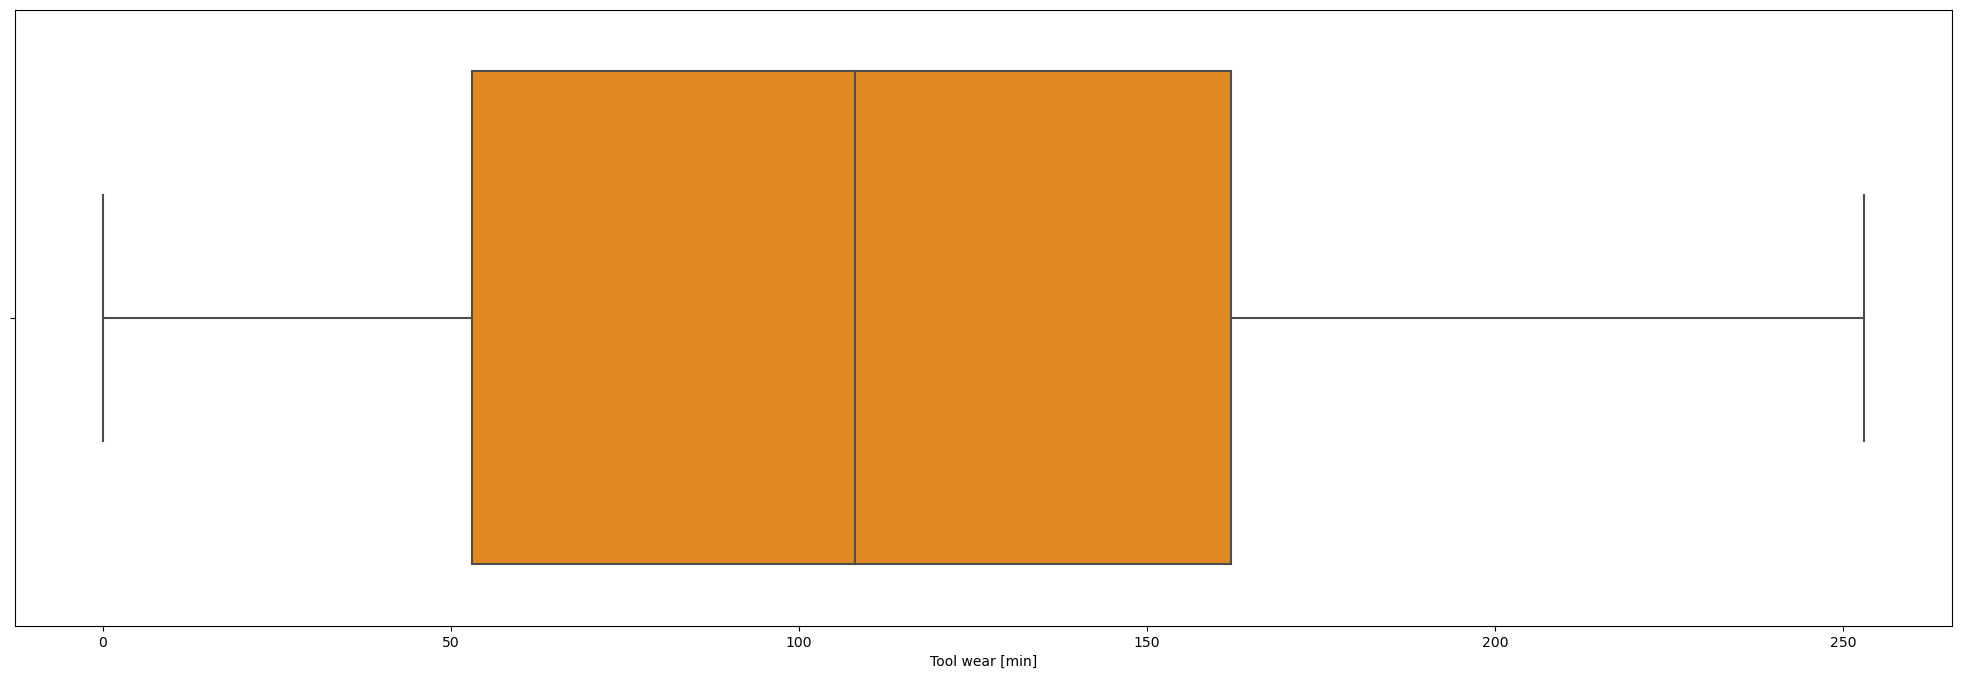

In [39]:
for col in sayisal_degiskenler:
    outlier_th(df,col)

In [40]:
def num_of_outliers(dataframe,col,q1=0.15,q3=0.85):#This function takes num of outliers and returns
    quar1 = dataframe[col].quantile(q1)
    quar3 = dataframe[col].quantile(q3)
    
    iqr = quar3 - quar1
    
    low_Limit = quar1 - 1.5 * iqr
    up_Limit = quar3 + 1.5 * iqr
    
    outliers = dataframe[(dataframe[col] < low_Limit) | (dataframe[col] > up_Limit)]
    
    return len(outliers)

In [41]:
def outliers_listele(dataframe,sayisal_degiskenler):#This function lists that if numeric variables have outliers 
    outliers_list = [col for col in sayisal_degiskenler if num_of_outliers(dataframe,col) > 0]
    
    return outliers_list

In [42]:
out_list = outliers_listele(df,sayisal_degiskenler)
out_list

['Rotational speed [rpm]']

In [43]:
def print_outliers_num(dataframe,sayisal_degiskenler):#This function prints num of outliers and ratio of all data
    sayac = 0
    for col in sayisal_degiskenler:
        out_len = num_of_outliers(dataframe,col)
        print(f"{col} outliers sayisi : {out_len} \n")
        sayac += out_len
        
    print(f"Toplam outliers sayısı {sayac} \n")
    print(f"Tum veriye oranı : {sayac / len(dataframe) * 100}")

In [44]:
print_outliers_num(df,sayisal_degiskenler)

Air temperature [K] outliers sayisi : 0 

Process temperature [K] outliers sayisi : 0 

Rotational speed [rpm] outliers sayisi : 131 

Torque [Nm] outliers sayisi : 0 

Tool wear [min] outliers sayisi : 0 

Toplam outliers sayısı 131 

Tum veriye oranı : 1.3111800620558502


In [45]:
def replace_with_th(dataframe,outliers_list): #This function for outliers to replace with threshold
    for col in outliers_list:
        low_limit,up_limit = outlier_th(dataframe,col,plot=False)
        
        dataframe.loc[dataframe[col] < low_limit,col] = low_limit
        dataframe.loc[dataframe[col] > up_limit,col] = up_limit

In [46]:
def remove_outlier(dataframe,col_name): #This function for outliers to remove these data
    lowLimit,upLimit = outlier_th(dataframe,col_name,q1=0.15,q3=0.85,plot=False)
    
    new_df = dataframe.loc[~((dataframe[col_name] < lowLimit) | (dataframe[col_name] > upLimit))]
    
    return new_df

In [47]:
df = remove_outlier(df,"Rotational speed [rpm]")

In [48]:
df = remove_outlier(df,"Rotational speed [rpm]")

In [49]:
print_outliers_num(df,sayisal_degiskenler)

Air temperature [K] outliers sayisi : 0 

Process temperature [K] outliers sayisi : 0 

Rotational speed [rpm] outliers sayisi : 0 

Torque [Nm] outliers sayisi : 0 

Tool wear [min] outliers sayisi : 0 

Toplam outliers sayısı 0 

Tum veriye oranı : 0.0


In [50]:
df.shape

(9847, 9)

In [51]:
clf = LocalOutlierFactor(n_neighbors=20) #Local Outlier Factor
clf.fit_predict(df[sayisal_degiskenler])
df_scores = clf.negative_outlier_factor_
df_scores

array([-1.05713834, -1.01177761, -1.08025981, ..., -1.02103182,
       -0.97681639, -0.98613177])

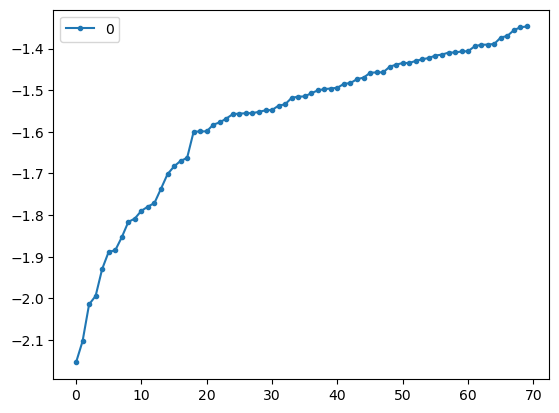

In [52]:
scores = pd.DataFrame(np.sort(df_scores)) #Plotting data
scores[0:70].plot(style='.-')
plt.show()

In [53]:
np.sort(df_scores)[0:50]

array([-2.15394659, -2.10304713, -2.01441458, -1.99414154, -1.92947168,
       -1.88804193, -1.88463751, -1.85326138, -1.81648128, -1.80813591,
       -1.78961305, -1.77964237, -1.77091154, -1.73669005, -1.7017565 ,
       -1.68299688, -1.66986669, -1.66253527, -1.59960507, -1.59906472,
       -1.59868454, -1.58282268, -1.57719739, -1.56798853, -1.55737943,
       -1.55620368, -1.55524987, -1.5549659 , -1.5518498 , -1.54827893,
       -1.54753163, -1.53695806, -1.53389759, -1.51822727, -1.51545561,
       -1.51485139, -1.50720033, -1.50044398, -1.4972343 , -1.49588729,
       -1.49402309, -1.48463693, -1.48284647, -1.47327739, -1.46988824,
       -1.45814036, -1.45705667, -1.45699136, -1.44367231, -1.43840651])

In [54]:
np.sort(df_scores)[18]

-1.5996050697424702

In [55]:
th = np.sort(df_scores)[18]
df[df_scores < th].shape

(18, 9)

In [56]:
df[df_scores < th].index

Int64Index([168, 592, 761, 994, 2863, 2864, 5033, 5399, 5400, 5401, 5999, 6404, 7763, 8307, 8437, 9667, 9670, 9671], dtype='int64')

In [57]:
df.drop(list(df[df_scores < th].index),axis=0,inplace=True)

In [58]:
df.shape

(9829, 9)

In [59]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Date
0,M,298.10,308.60,1551,42.80,0,0,No Failure,2024-01-01 00:00:00
1,L,298.20,308.70,1408,46.30,3,0,No Failure,2024-01-01 00:15:00
2,L,298.10,308.50,1498,49.40,5,0,No Failure,2024-01-01 00:30:00
3,L,298.20,308.60,1433,39.50,7,0,No Failure,2024-01-01 00:45:00
4,L,298.20,308.70,1408,40.00,9,0,No Failure,2024-01-01 01:00:00


In [60]:
def Corr_analys(dataframe,figsize=(14,14),save=False): #This function performs correlation analysis
    corr = dataframe.corr()
    
    plt.figure(figsize=figsize)
    heatmap = sns.heatmap(data = corr,vmin = -1,vmax = 1,annot = True,cmap = sns.color_palette("crest", as_cmap=True),fmt=".2f")
    plt.show()
    
    if save:
        heatmap.get_figure().savefig("korelasyon_heatmap.png")

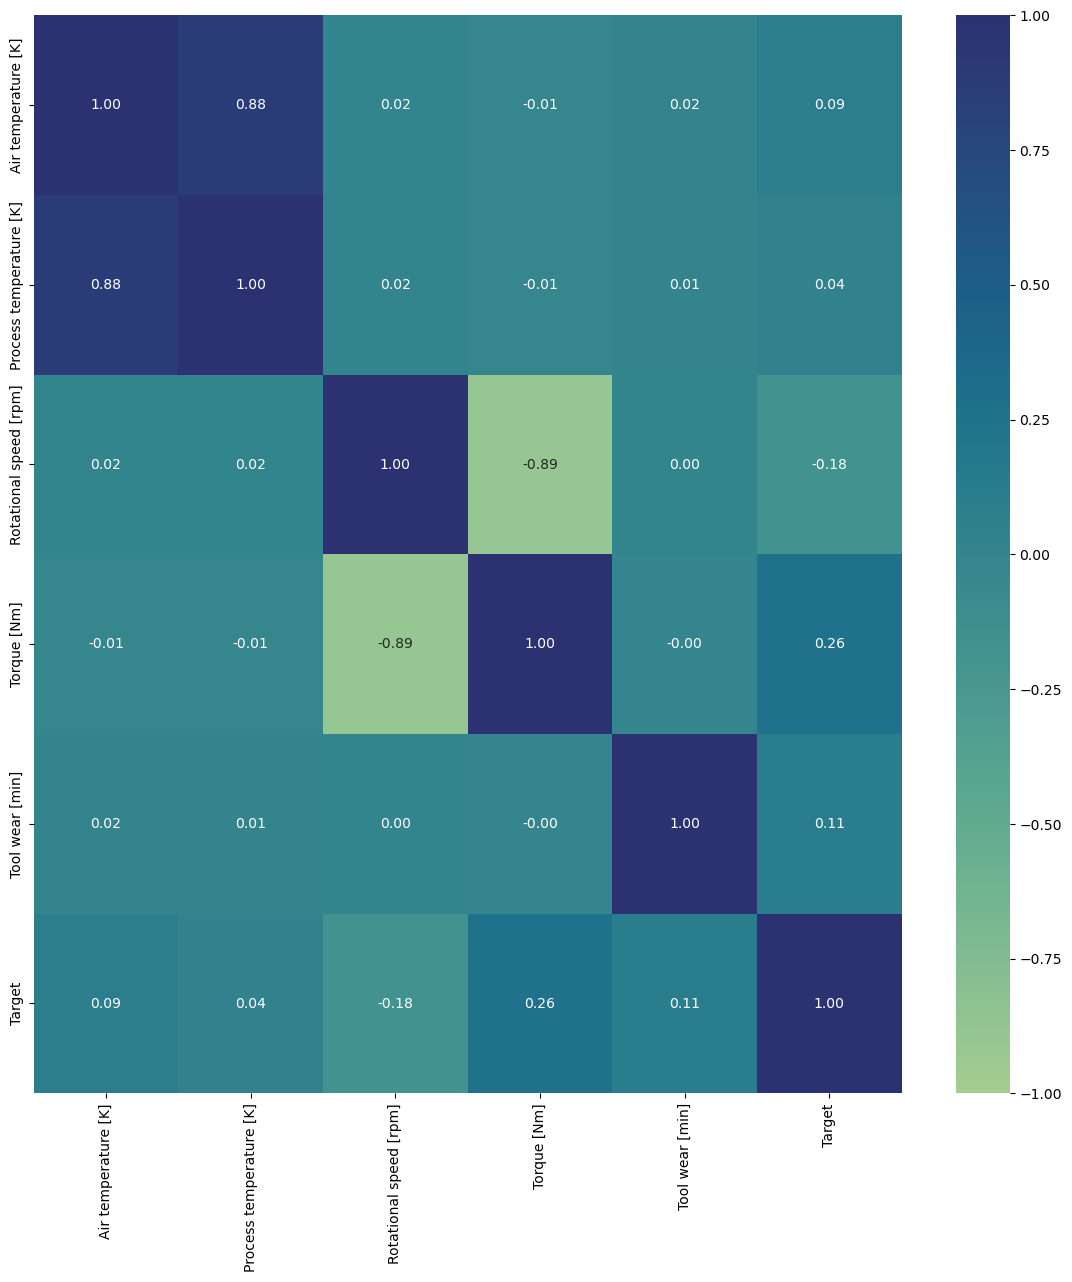

In [61]:
Corr_analys(df,save=False)

In [62]:
df.head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Date
0,M,298.10,308.60,1551,42.80,0,0,No Failure,2024-01-01 00:00:00
1,L,298.20,308.70,1408,46.30,3,0,No Failure,2024-01-01 00:15:00
2,L,298.10,308.50,1498,49.40,5,0,No Failure,2024-01-01 00:30:00
3,L,298.20,308.60,1433,39.50,7,0,No Failure,2024-01-01 00:45:00
4,L,298.20,308.70,1408,40.00,9,0,No Failure,2024-01-01 01:00:00
5,M,298.10,308.60,1425,41.90,11,0,No Failure,2024-01-01 01:15:00
6,L,298.10,308.60,1558,42.40,14,0,No Failure,2024-01-01 01:30:00
7,L,298.10,308.60,1527,40.20,16,0,No Failure,2024-01-01 01:45:00
8,M,298.30,308.70,1667,28.60,18,0,No Failure,2024-01-01 02:00:00
9,M,298.50,309.00,1741,28.00,21,0,No Failure,2024-01-01 02:15:00


In [63]:
df.loc[df["Target"] == 1]

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Date
69,L,298.90,309.00,1410,65.70,191,1,Power Failure,2024-01-01 17:15:00
77,L,298.80,308.90,1455,41.30,208,1,Tool Wear Failure,2024-01-01 19:15:00
160,L,298.40,308.20,1282,60.70,216,1,Overstrain Failure,2024-01-02 16:00:00
161,L,298.30,308.10,1412,52.30,218,1,Overstrain Failure,2024-01-02 16:15:00
207,M,298.40,308.70,1421,60.70,119,1,Power Failure,2024-01-03 03:45:00
242,L,298.00,308.20,1348,58.80,202,1,Overstrain Failure,2024-01-03 12:30:00
248,L,298.00,308.30,1362,56.80,216,1,Overstrain Failure,2024-01-03 14:00:00
249,L,298.00,308.30,1405,56.20,218,1,Overstrain Failure,2024-01-03 14:15:00
259,M,298.10,308.20,1420,63.90,19,1,Power Failure,2024-01-03 16:45:00
327,L,297.70,308.50,1373,56.70,203,1,Overstrain Failure,2024-01-04 09:45:00


In [64]:
df[sayisal_degiskenler].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],9829.00,300.00,2.00,295.30,298.30,300.10,301.50,304.50
Process temperature [K],9829.00,310.00,1.48,305.70,308.80,310.10,311.10,313.80
Rotational speed [rpm],9829.00,1527.21,149.56,1192.00,1422.00,1501.00,1606.00,2109.00
Torque [Nm],9829.00,40.33,9.54,16.70,33.50,40.20,46.80,76.20
Tool wear [min],9829.00,107.79,63.49,0.00,53.00,108.00,162.00,244.00


In [65]:
df["Failure Type"].value_counts()

No Failure                  9523
Heat Dissipation Failure     112
Overstrain Failure            74
Power Failure                 61
Tool Wear Failure             41
Random Failures               18
Name: Failure Type, dtype: int64

In [66]:
df.groupby("Type")["Failure Type"].value_counts()

Type  Failure Type            
H     No Failure                   964
      Heat Dissipation Failure       8
      Tool Wear Failure              5
      Power Failure                  4
      Random Failures                4
L     No Failure                  5679
      Heat Dissipation Failure      74
      Overstrain Failure            70
      Power Failure                 37
      Tool Wear Failure             24
      Random Failures               12
M     No Failure                  2880
      Heat Dissipation Failure      30
      Power Failure                 20
      Tool Wear Failure             12
      Overstrain Failure             4
      Random Failures                2
Name: Failure Type, dtype: int64

In [67]:
df.groupby("Failure Type")["Tool wear [min]"].mean()

Failure Type
Heat Dissipation Failure   107.34
No Failure                 106.55
Overstrain Failure         206.80
Power Failure              108.13
Random Failures            119.89
Tool Wear Failure          214.49
Name: Tool wear [min], dtype: float64

In [68]:
df.groupby("Failure Type")["Rotational speed [rpm]"].mean()

Failure Type
Heat Dissipation Failure   1337.96
No Failure                 1531.92
Overstrain Failure         1354.19
Power Failure              1340.39
Random Failures            1489.44
Tool Wear Failure          1558.63
Name: Rotational speed [rpm], dtype: float64

In [69]:
df.groupby("Failure Type")["Torque [Nm]"].mean()

Failure Type
Heat Dissipation Failure   52.78
No Failure                 39.89
Overstrain Failure         57.05
Power Failure              66.72
Random Failures            43.52
Tool Wear Failure          37.22
Name: Torque [Nm], dtype: float64

In [70]:
df.groupby("Failure Type")["Air temperature [K]"].mean()

Failure Type
Heat Dissipation Failure   302.57
No Failure                 299.97
Overstrain Failure         299.81
Power Failure              300.05
Random Failures            300.77
Tool Wear Failure          300.26
Name: Air temperature [K], dtype: float64

In [71]:
df.groupby("Failure Type")["Process temperature [K]"].mean()

Failure Type
Heat Dissipation Failure   310.80
No Failure                 309.99
Overstrain Failure         309.99
Power Failure              309.92
Random Failures            310.76
Tool Wear Failure          310.14
Name: Process temperature [K], dtype: float64

In [72]:
df.groupby("Type")["Air temperature [K]"].mean()

Type
H   299.87
L   300.02
M   300.01
Name: Air temperature [K], dtype: float64

In [73]:
df.groupby("Type")["Process temperature [K]"].mean()

Type
H   309.92
L   310.01
M   310.01
Name: Process temperature [K], dtype: float64

In [74]:
df.groupby("Type")["Rotational speed [rpm]"].mean()

Type
H   1527.40
L   1527.23
M   1527.11
Name: Rotational speed [rpm], dtype: float64

In [75]:
df.groupby("Type")["Torque [Nm]"].mean()

Type
H   40.17
L   40.36
M   40.32
Name: Torque [Nm], dtype: float64

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9829 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Type                     9829 non-null   object        
 1   Air temperature [K]      9829 non-null   float64       
 2   Process temperature [K]  9829 non-null   float64       
 3   Rotational speed [rpm]   9829 non-null   int64         
 4   Torque [Nm]              9829 non-null   float64       
 5   Tool wear [min]          9829 non-null   int64         
 6   Target                   9829 non-null   int64         
 7   Failure Type             9829 non-null   object        
 8   Date                     9829 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 767.9+ KB


In [77]:
df.to_csv("C:\\Users\\Ali Can\\Desktop\\Proje\\DinamikProje\\data\\interim\\intermadiate_data_after_data_analysis.csv",index=False)